# Avance de proyecto — Riesgo comercial de películas

**Dataset:** TMDB 5000 Movie Dataset  
**Enfoque:** Clasificación binaria  
**Variable objetivo:** `CommercialRisk`

En este proyecto se busca analizar si los datos disponibles de una película antes o alrededor de su estreno pueden ayudar a identificar si existe riesgo de que no recupere su presupuesto en taquilla.

La idea no es predecir exactamente cuánto dinero va a generar una película, sino construir una clasificación sencilla: **riesgo comercial o no riesgo comercial**. A partir de esto se compararán distintos modelos y se revisará principalmente qué tan bien detectan las películas que sí presentan riesgo.

## Librerías utilizadas

In [ ]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Análisis de la situación del proyecto

Antes de producir o lanzar una película se toman decisiones importantes sobre presupuesto, distribución y uso de recursos. El problema es que el resultado comercial depende de muchos factores y no siempre es fácil saber qué proyectos tienen más riesgo.

Por eso, este proyecto plantea usar información histórica de películas para buscar patrones que ayuden a identificar proyectos con mayor probabilidad de no superar su presupuesto en taquilla.

El modelo se plantea como una herramienta de apoyo para tomar decisiones con más información, no como una forma de asegurar el éxito o fracaso de una película.

## 2. Selección y registro del dataset

| Elemento | Información |
|---|---|
| **Nombre del dataset** | TMDB 5000 Movie Dataset |
| **Fuente** | The Movie Database (TMDB) / Kaggle |
| **Liga de acceso** | https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata |
| **Archivos principales** | `tmdb_5000_movies.csv`, `tmdb_5000_credits.csv` |

El dataset contiene información de películas como presupuesto, ingresos, duración, géneros, idioma, fecha de estreno y datos del equipo creativo. Cada registro representa una película.

Para este proyecto se combinan los archivos de películas y créditos para tener en un mismo conjunto las variables necesarias para el análisis.

## 3. Definición del problema de aprendizaje automático

El problema consiste en identificar si una película tiene riesgo de **no superar en taquilla su presupuesto de producción** usando variables que puedan conocerse antes o alrededor del estreno.

Se trata de un problema de **clasificación binaria**:

- `CommercialRisk = 0`: la película superó su presupuesto en taquilla.
- `CommercialRisk = 1`: la película no superó su presupuesto en taquilla.

La clase positiva es `CommercialRisk = 1`, porque es la que interesa detectar.

Como criterio principal se dará más importancia al `recall`, ya que un falso negativo significaría clasificar una película como de bajo riesgo cuando en realidad sí presenta riesgo comercial.

## 4. Pregunta de análisis

**¿Qué tan bien se puede identificar el riesgo comercial de una película usando información como presupuesto, género, duración, fecha de estreno y equipo creativo mediante un modelo de aprendizaje automático reproducible?**

## 5. Diccionario de variables

El dataset se forma a partir de dos archivos de TMDB: uno con información general de las películas y otro con créditos.

A continuación se documentan las variables más importantes del dataset, qué representa cada una y cuáles se utilizarán durante el proyecto.

In [ ]:
diccionario = pd.DataFrame([
    ["budget", "Presupuesto de producción reportado.", "Numérica", "Predictora", "Mantener; revisar ceros y valores extremos."],
    ["genres", "Géneros almacenados como texto estructurado.", "Texto estructurado", "Fuente de variable", "Extraer género principal."],
    ["homepage", "Sitio web oficial.", "Texto", "Excluir", "Muchos faltantes y poca utilidad para la línea base."],
    ["id", "Identificador único de TMDB.", "ID", "Excluir", "No aporta valor predictivo directo."],
    ["keywords", "Palabras clave asociadas a la película.", "Texto estructurado", "Excluir en línea base", "Requeriría procesamiento adicional."],
    ["original_language", "Idioma original.", "Categórica", "Predictora", "Codificación categórica."],
    ["original_title", "Título original.", "Texto", "Excluir", "Alta cardinalidad."],
    ["overview", "Sinopsis.", "Texto", "Excluir en línea base", "Requeriría NLP."],
    ["popularity", "Índice de popularidad de TMDB.", "Numérica", "Excluir", "Puede contener información posterior al estreno."],
    ["production_companies", "Compañías productoras.", "Texto estructurado", "Fuente de variable", "Extraer productora principal."],
    ["production_countries", "Países de producción.", "Texto estructurado", "Fuente de variable", "Extraer país principal si se necesita."],
    ["release_date", "Fecha de estreno.", "Fecha", "Fuente de variable", "Convertir a año y mes."],
    ["revenue", "Ingresos de taquilla reportados.", "Numérica", "Solo para crear objetivo", "No usar como predictor."],
    ["runtime", "Duración en minutos.", "Numérica", "Predictora", "Revisar faltantes y rangos."],
    ["spoken_languages", "Idiomas hablados.", "Texto estructurado", "Excluir en línea base", "No necesario para la primera versión."],
    ["status", "Estado del registro.", "Categórica", "Excluir", "Poca utilidad y posible información temporal."],
    ["tagline", "Frase promocional.", "Texto", "Excluir en línea base", "Muchos faltantes."],
    ["title", "Título comercial.", "Texto", "Excluir", "Alta cardinalidad."],
    ["vote_average", "Promedio de votos de usuarios.", "Numérica", "Excluir", "Información posterior al estreno."],
    ["vote_count", "Número de votos de usuarios.", "Numérica", "Excluir", "Información posterior al estreno."],
    ["cast", "Reparto almacenado como texto estructurado.", "Texto estructurado", "Fuente de variable", "Extraer actor o actriz principal."],
    ["crew", "Equipo creativo/técnico.", "Texto estructurado", "Fuente de variable", "Extraer director y guionista."],
    ["primary_genre", "Primer género listado.", "Categórica derivada", "Predictora", "Codificación categórica."],
    ["production_company", "Primera compañía listada.", "Categórica derivada", "Predictora", "Agrupar categorías poco frecuentes si es necesario."],
    ["director", "Director principal.", "Categórica derivada", "Predictora", "Agrupar categorías poco frecuentes."],
    ["writer", "Guionista principal.", "Categórica derivada", "Predictora", "Agrupar categorías poco frecuentes."],
    ["lead_actor", "Primer integrante del reparto.", "Categórica derivada", "Predictora", "Agrupar categorías poco frecuentes."],
    ["release_year", "Año de estreno.", "Numérica derivada", "Predictora", "Mantener."],
    ["release_month", "Mes de estreno.", "Categórica derivada", "Predictora", "Codificación categórica."],
    ["CommercialRisk", "Indica si la taquilla no superó el presupuesto.", "Binaria derivada", "Objetivo", "1 = riesgo; 0 = superó presupuesto."]
], columns=["Variable", "Descripción", "Tipo analítico", "Rol", "Tratamiento previsto"])

display(diccionario)

,Variable,Descripción,Tipo analítico,Rol,Tratamiento previsto
0,budget,Presupuesto de producción reportado.,Numérica,Predictora,Mantener; revisar ceros y valores extremos.
1,genres,Géneros almacenados como texto estructurado.,Texto estructurado,Fuente de variable,Extraer género principal.
2,homepage,Sitio web oficial.,Texto,Excluir,Muchos faltantes y poca utilidad para la línea...
3,id,Identificador único de TMDB.,ID,Excluir,No aporta valor predictivo directo.
4,keywords,Palabras clave asociadas a la película.,Texto estructurado,Excluir en línea base,Requeriría procesamiento adicional.
5,original_language,Idioma original.,Categórica,Predictora,Codificación categórica.
6,original_title,Título original.,Texto,Excluir,Alta cardinalidad.
7,overview,Sinopsis.,Texto,Excluir en línea base,Requeriría NLP.
8,popularity,Índice de popularidad de TMDB.,Numérica,Excluir,Puede contener información posterior al estreno.
9,production_companies,Compañías productoras.,Texto estructurado,Fuente de variable,Extraer productora principal.


### Variables que no se utilizarán como predictoras

`id`, `title` y `original_title` se excluyen por funcionar como identificadores o tener una cardinalidad muy alta.

`revenue` se utiliza para construir la variable objetivo y **no puede utilizarse como predictor**, ya que produciría fuga de información.

`popularity`, `vote_average` y `vote_count` también se excluyen porque reflejan información generada principalmente después del estreno.

Las variables de texto libre como `overview`, `tagline` y `keywords` se dejan fuera de la línea base para mantener un proceso reproducible y manejable. Podrían incorporarse más adelante mediante técnicas de procesamiento de lenguaje natural.

## 6. Carga y exploración inicial

Primero se cargan los dos archivos del dataset y se unen usando el identificador de cada película.

Antes de limpiar o transformar los datos se revisa su estructura general para entender con qué estamos trabajando y detectar posibles problemas desde el inicio.

### Carga de los archivos

In [ ]:
archivo_movies = "tmdb_5000_movies.csv"
archivo_credits = "tmdb_5000_credits.csv"

if not (os.path.exists(archivo_movies) and os.path.exists(archivo_credits)):
    from google.colab import files
    print("Sube tmdb_5000_movies.csv y tmdb_5000_credits.csv")
    uploaded = files.upload()

movies = pd.read_csv(archivo_movies)
credits = pd.read_csv(archivo_credits)

print("Movies:", movies.shape)
print("Credits:", credits.shape)

Sube tmdb_5000_movies.csv y tmdb_5000_credits.csv


Saving tmdb_5000_credits.csv to tmdb_5000_credits (1).csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv
Movies: (4803, 20)
Credits: (4803, 4)


### Unión de los archivos

In [ ]:
credits_merge = credits[["movie_id", "cast", "crew"]].copy()

df = movies.merge(
    credits_merge,
    left_on="id",
    right_on="movie_id",
    how="left"
)

df.drop(columns=["movie_id"], inplace=True)
print("Dimensiones después de la unión:", df.shape)

Dimensiones después de la unión: (4803, 22)


### Primeras observaciones

In [ ]:
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


Las primeras observaciones confirman que cada fila representa una película y que el dataset incluye información financiera, de producción, estreno y equipo creativo.

### Últimas observaciones

In [ ]:
df.tail()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
4798,220000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",NaN,9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,"[{""name"": ""Columbia Pictures"", ""id"": 5}]",...,2040920,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,9000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",NaN,72766,[],en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,[],...,0,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,0,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",http://www.hallmarkchannel.com/signedsealeddel...,231617,"[{""id"": 248, ""name"": ""date""}, {""id"": 699, ""nam...",en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,"[{""name"": ""Front Street Pictures"", ""id"": 3958}...",...,0,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,"Signed, Sealed, Delivered",7.0,6,"[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,0,[],http://shanghaicalling.com/,126186,[],en,Shanghai Calling,When ambitious New York attorney Sam is sent t...,0.857008,[],...,0,98.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,A New Yorker in Shanghai,Shanghai Calling,5.7,7,"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."
4802,0,"[{""id"": 99, ""name"": ""Documentary""}]",NaN,25975,"[{""id"": 1523, ""name"": ""obsession""}, {""id"": 224...",en,My Date with Drew,Ever since the second grade when he first saw ...,1.929883,"[{""name"": ""rusty bear entertainment"", ""id"": 87...",...,0,90.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,My Date with Drew,6.3,16,"[{""cast_id"": 3, ""character"": ""Herself"", ""credi...","[{""credit_id"": ""58ce021b9251415a390165d9"", ""de..."


### Número de filas y columnas

In [ ]:
print("Número de películas:", df.shape[0])
print("Número de variables:", df.shape[1])

Número de películas: 4803
Número de variables: 22


### Nombres de las variables

In [ ]:
df.columns.tolist()

['budget',
 'genres',
 'homepage',
 'id',
 'keywords',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'production_companies',
 'production_countries',
 'release_date',
 'revenue',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'vote_average',
 'vote_count',
 'cast',
 'crew']

### Tipos de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

Esta revisión sirve para saber qué variables ya tienen el tipo correcto y cuáles necesitan algún ajuste. Por ejemplo, `release_date` requiere conversión a fecha, mientras que columnas como `genres`, `cast` y `crew` contienen estructuras guardadas como texto.

### Estadísticas descriptivas

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
budget,4803.0,2.904504e+07,4.072239e+07,0.0,790000.00000,1.500000e+07,4.000000e+07,3.800000e+08
id,4803.0,5.716548e+04,8.869461e+04,5.0,9014.50000,1.462900e+04,5.861050e+04,4.594880e+05
popularity,4803.0,2.149230e+01,3.181665e+01,0.0,4.66807,1.292159e+01,2.831350e+01,8.755813e+02
revenue,4803.0,8.226064e+07,1.628571e+08,0.0,0.00000,1.917000e+07,9.291719e+07,2.787965e+09
runtime,4801.0,1.068759e+02,2.261193e+01,0.0,94.00000,1.030000e+02,1.180000e+02,3.380000e+02
vote_average,4803.0,6.092172e+00,1.194612e+00,0.0,5.60000,6.200000e+00,6.800000e+00,1.000000e+01
vote_count,4803.0,6.902180e+02,1.234586e+03,0.0,54.00000,2.350000e+02,7.370000e+02,1.375200e+04


Las estadísticas permiten tener una primera idea del rango y comportamiento de las variables numéricas.

En particular, conviene revisar los valores de `budget` y `revenue`, porque aparecen varios ceros que pueden significar información no reportada y afectar directamente la forma en que se construye la variable objetivo.

### Número de valores únicos por variable

In [ ]:
df.nunique().sort_values()

,0
status,3
original_language,37
vote_average,71
runtime,156
budget,436
production_countries,469
spoken_languages,544
genres,1175
vote_count,1609
homepage,1691


### Valores faltantes

In [ ]:
faltantes = pd.DataFrame({
    "Faltantes": df.isnull().sum(),
    "Porcentaje": (df.isnull().mean() * 100).round(2)
}).sort_values("Faltantes", ascending=False)

faltantes[faltantes["Faltantes"] > 0]

,Faltantes,Porcentaje
homepage,3091,64.36
tagline,844,17.57
overview,3,0.06
runtime,2,0.04
release_date,1,0.02


### Registros duplicados

In [ ]:
print("Filas completamente duplicadas:", df.duplicated().sum())
print("IDs duplicados:", df["id"].duplicated().sum())

Filas completamente duplicadas: 0
IDs duplicados: 0


### Preparación mínima de la variable objetivo

Para saber si una película superó su presupuesto se necesitan valores válidos tanto de `budget` como de `revenue`.

Los registros con cero en cualquiera de estas dos variables se mantienen en el dataset original, pero no se utilizan en `df_model`, ya que con esos datos no se puede determinar de forma confiable si la película recuperó su presupuesto.

La variable `CommercialRisk` se define así:

- `0`: `revenue > budget`
- `1`: `revenue <= budget`

In [ ]:
print("Películas con budget <= 0:", (df["budget"] <= 0).sum())
print("Películas con revenue <= 0:", (df["revenue"] <= 0).sum())

df_model = df[(df["budget"] > 0) & (df["revenue"] > 0)].copy()

df_model["CommercialRisk"] = (df_model["revenue"] <= df_model["budget"]).astype(int)

print("Dataset original:", df.shape)
print("Dataset con objetivo válido:", df_model.shape)

Películas con budget <= 0: 1037
Películas con revenue <= 0: 1427
Dataset original: (4803, 22)
Dataset con objetivo válido: (3229, 23)


### Distribución inicial de la variable objetivo

In [ ]:
distribucion_objetivo = pd.DataFrame({
    "Cantidad": df_model["CommercialRisk"].value_counts().sort_index(),
    "Porcentaje": df_model["CommercialRisk"].value_counts(normalize=True).sort_index().mul(100).round(2)
})

distribucion_objetivo.index = ["0 - Superó presupuesto", "1 - No superó presupuesto"]
distribucion_objetivo

,Cantidad,Porcentaje
0 - Superó presupuesto,2438,75.5
1 - No superó presupuesto,791,24.5


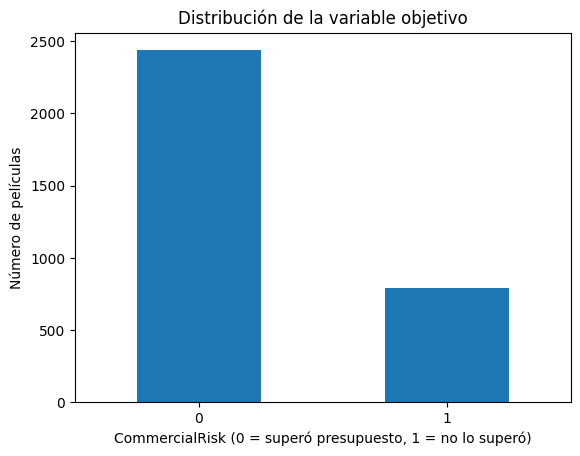

In [ ]:
df_model["CommercialRisk"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la variable objetivo")
plt.xlabel("CommercialRisk (0 = superó presupuesto, 1 = no lo superó)")
plt.ylabel("Número de películas")
plt.xticks(rotation=0)
plt.show()

### Variables derivadas para el análisis

In [ ]:
def parse_list(value):
    if pd.isna(value):
        return []
    try:
        result = ast.literal_eval(value)
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

def first_name(value):
    items = parse_list(value)
    if items and isinstance(items[0], dict):
        return items[0].get("name", np.nan)
    return np.nan

def crew_name(value, jobs):
    items = parse_list(value)
    for item in items:
        if isinstance(item, dict) and item.get("job") in jobs:
            return item.get("name", np.nan)
    return np.nan

df_model["primary_genre"] = df_model["genres"].apply(first_name)
df_model["production_company"] = df_model["production_companies"].apply(first_name)
df_model["lead_actor"] = df_model["cast"].apply(first_name)
df_model["director"] = df_model["crew"].apply(lambda x: crew_name(x, {"Director"}))
df_model["writer"] = df_model["crew"].apply(lambda x: crew_name(x, {"Writer", "Screenplay"}))

df_model["release_date"] = pd.to_datetime(df_model["release_date"], errors="coerce")
df_model["release_year"] = df_model["release_date"].dt.year
df_model["release_month"] = df_model["release_date"].dt.month

df_model[["title", "primary_genre", "production_company", "director", "writer", "lead_actor", "release_year", "release_month", "CommercialRisk"]].head()

,title,primary_genre,production_company,director,writer,lead_actor,release_year,release_month,CommercialRisk
0,Avatar,Action,Ingenious Film Partners,James Cameron,James Cameron,Sam Worthington,2009,12,0
1,Pirates of the Caribbean: At World's End,Adventure,Walt Disney Pictures,Gore Verbinski,Ted Elliott,Johnny Depp,2007,5,0
2,Spectre,Action,Columbia Pictures,Sam Mendes,John Logan,Daniel Craig,2015,10,0
3,The Dark Knight Rises,Action,Legendary Pictures,Christopher Nolan,Christopher Nolan,Christian Bale,2012,7,0
4,John Carter,Action,Walt Disney Pictures,Andrew Stanton,Andrew Stanton,Taylor Kitsch,2012,3,0


## 7. Análisis de la calidad de los datos

En esta parte se revisan los problemas que podrían afectar el modelado: valores faltantes, duplicados, tipos de datos, categorías inconsistentes, valores extremos, alta cardinalidad, desbalance y posibles fugas de información.

La idea es no limpiar datos de forma automática, sino justificar qué se modifica y qué se conserva.

### Valores faltantes

In [ ]:
faltantes_modelo = pd.DataFrame({
    "Faltantes": df_model.isnull().sum(),
    "Porcentaje": (df_model.isnull().mean() * 100).round(2)
}).sort_values("Faltantes", ascending=False)

faltantes_modelo[faltantes_modelo["Faltantes"] > 0].head(20)

,Faltantes,Porcentaje
homepage,1882,58.28
tagline,245,7.59
writer,194,6.01
production_company,41,1.27
director,2,0.06
lead_actor,2,0.06
primary_genre,1,0.03


Los valores faltantes no se eliminan automáticamente. En las variables numéricas se podrán imputar valores y en las categóricas se podrá utilizar una categoría como `Unknown` cuando sea necesario.

Así se evita perder registros sin una razón suficiente.

### Registros duplicados

In [ ]:
print("Filas duplicadas en df_model:", df_model.duplicated().sum())
print("IDs duplicados en df_model:", df_model["id"].duplicated().sum())

Filas duplicadas en df_model: 0
IDs duplicados en df_model: 0


### Categorías inconsistentes y espacios

In [ ]:
categorias_revision = ["original_language", "primary_genre", "production_company", "director", "writer", "lead_actor"]

for col in categorias_revision:
    print(f"\n--- {col} ---")
    serie = df_model[col].dropna().astype(str)
    print("Espacios al inicio/final:", (serie != serie.str.strip()).sum())
    print("Ejemplos:", serie.value_counts().head(10).to_dict())


--- original_language ---
Espacios al inicio/final: 0
Ejemplos: {'en': 3102, 'fr': 25, 'es': 15, 'ja': 13, 'zh': 13, 'de': 9, 'hi': 7, 'it': 6, 'ru': 6, 'cn': 5}

--- primary_genre ---
Espacios al inicio/final: 0
Ejemplos: {'Drama': 747, 'Comedy': 634, 'Action': 588, 'Adventure': 288, 'Horror': 197, 'Crime': 141, 'Thriller': 118, 'Animation': 99, 'Fantasy': 93, 'Science Fiction': 79}

--- production_company ---
Espacios al inicio/final: 0
Ejemplos: {'Paramount Pictures': 241, 'Universal Pictures': 228, 'Columbia Pictures': 166, 'Twentieth Century Fox Film Corporation': 159, 'New Line Cinema': 135, 'Walt Disney Pictures': 96, 'Village Roadshow Pictures': 64, 'United Artists': 61, 'Miramax Films': 61, 'Columbia Pictures Corporation': 58}

--- director ---
Espacios al inicio/final: 3
Ejemplos: {'Steven Spielberg': 27, 'Clint Eastwood': 19, 'Martin Scorsese': 16, 'Ridley Scott': 16, 'Robert Rodriguez': 16, 'Renny Harlin': 15, 'Steven Soderbergh': 14, 'Tim Burton': 14, 'Robert Zemeckis': 1

Aquí se revisan posibles diferencias de escritura o espacios. En variables como director, guionista o productora no conviene unir categorías solamente porque se parecen, ya que podrían representar personas o empresas diferentes.

### Columnas numéricas almacenadas como texto

In [ ]:
columnas_numericas_esperadas = ["budget", "revenue", "runtime", "popularity", "vote_average", "vote_count"]

revision_tipos = pd.DataFrame({
    "Variable": columnas_numericas_esperadas,
    "Tipo actual": [str(df_model[col].dtype) for col in columnas_numericas_esperadas],
    "No convertibles": [
        pd.to_numeric(df_model[col], errors="coerce").isnull().sum() - df_model[col].isnull().sum()
        for col in columnas_numericas_esperadas
    ]
})

revision_tipos

,Variable,Tipo actual,No convertibles
0,budget,int64,0
1,revenue,int64,0
2,runtime,float64,0
3,popularity,float64,0
4,vote_average,float64,0
5,vote_count,int64,0


### Valores atípicos mediante IQR

In [ ]:
resultados_iqr = []

for col in ["budget", "runtime"]:
    serie = df_model[col].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    n_outliers = ((serie < li) | (serie > ls)).sum()
    resultados_iqr.append([col, q1, q3, li, ls, n_outliers])

pd.DataFrame(resultados_iqr, columns=["Variable", "Q1", "Q3", "Límite inferior", "Límite superior", "Atípicos IQR"])

,Variable,Q1,Q3,Límite inferior,Límite superior,Atípicos IQR
0,budget,10500000.0,55000000.0,-56250000.0,121750000.0,216
1,runtime,96.0,121.0,58.5,158.5,99


En este dataset es normal encontrar películas con presupuestos muy altos o duraciones poco comunes. Por eso, que un dato aparezca como atípico por IQR no significa automáticamente que sea incorrecto.

Primero se revisa si el valor sigue teniendo sentido dentro del contexto antes de considerar eliminarlo.

### Rangos imposibles o poco razonables

In [ ]:
rangos = pd.DataFrame({
    "Variable": ["budget", "revenue", "runtime", "release_year"],
    "Mínimo": [df_model["budget"].min(), df_model["revenue"].min(), df_model["runtime"].min(), df_model["release_year"].min()],
    "Máximo": [df_model["budget"].max(), df_model["revenue"].max(), df_model["runtime"].max(), df_model["release_year"].max()]
})

rangos

,Variable,Mínimo,Máximo
0,budget,1.0,3.800000e+08
1,revenue,5.0,2.787965e+09
2,runtime,41.0,3.380000e+02
3,release_year,1916.0,2.016000e+03


### Variables con una sola categoría o demasiadas categorías

In [ ]:
cardinalidad = df_model.nunique().sort_values()

print("Variables con una sola categoría:")
print(cardinalidad[cardinalidad <= 1])

print("\nVariables con más de 100 categorías:")
print(cardinalidad[cardinalidad > 100])

Variables con una sola categoría:
Series([], dtype: int64)

Variables con más de 100 categorías:
runtime                  136
production_countries     319
budget                   385
spoken_languages         439
production_company       753
genres                   933
lead_actor              1300
homepage                1326
director                1444
vote_count              1586
writer                  1704
release_date            2494
production_companies    2633
tagline                 2976
keywords                3099
revenue                 3154
title                   3228
cast                    3228
crew                    3228
original_title          3229
overview                3229
popularity              3229
id                      3229
dtype: int64


Variables como `title`, `original_title` e `id` tienen demasiados valores únicos y no serían buenas predictoras en su forma actual.

También hay alta cardinalidad en variables como `director`, `writer`, `lead_actor` y `production_company`. Si se incluyen, será necesario controlar las categorías poco frecuentes para evitar que el número de variables crezca demasiado.

### Posibles fugas de información

La variable más clara que no puede usarse como predictor es `revenue`, porque participa directamente en la creación de `CommercialRisk`.

También se excluyen `popularity`, `vote_average` y `vote_count`, ya que son datos que pueden reflejar lo ocurrido después del estreno. Usarlos haría que el modelo tuviera información que en una predicción real todavía no estaría disponible.

### Desbalance de la variable objetivo

In [ ]:
balance = pd.DataFrame({
    "Cantidad": df_model["CommercialRisk"].value_counts().sort_index(),
    "Porcentaje": df_model["CommercialRisk"].value_counts(normalize=True).sort_index().mul(100).round(2)
})

balance.index = ["0 - Superó presupuesto", "1 - No superó presupuesto"]
balance

,Cantidad,Porcentaje
0 - Superó presupuesto,2438,75.5
1 - No superó presupuesto,791,24.5


### Tabla de diagnóstico de calidad

In [ ]:
diagnostico = pd.DataFrame([
    ["Budget/revenue no reportados o en cero", "budget, revenue", f"budget <= 0: {(df['budget'] <= 0).sum()} | revenue <= 0: {(df['revenue'] <= 0).sum()}", "No permiten construir de forma confiable la variable objetivo.", "Conservar el dataset original y excluir estos casos solo del subconjunto de modelado."],
    ["Valores faltantes", "Varias columnas", f"{int(df_model.isnull().sum().sum())} celdas nulas antes del tratamiento.", "Algunas variables no pueden utilizarse directamente.", "Imputar dentro del pipeline según el tipo de variable."],
    ["Registros duplicados", "Dataset", f"{int(df_model.duplicated().sum())} filas completamente duplicadas.", "Podrían sobre-representar observaciones.", "Revisar IDs y eliminar solo si se confirma que son duplicados reales."],
    ["Categorías / espacios", "Variables categóricas", "Revisión de espacios y frecuencias realizada.", "Categorías equivalentes podrían tratarse como distintas.", "Normalizar espacios y conservar nombres distintos salvo evidencia de equivalencia."],
    ["Alta cardinalidad", "title, original_title, director, writer, lead_actor, production_company", "Muchas categorías únicas.", "Puede generar demasiadas variables al codificar.", "Excluir títulos/IDs y controlar categorías infrecuentes en variables creativas."],
    ["Valores atípicos", "budget, runtime", "Se revisan mediante IQR y boxplots.", "Pueden afectar algunos modelos, pero también representar películas reales.", "No eliminar automáticamente; revisar coherencia."],
    ["Posible fuga de información", "revenue, popularity, vote_average, vote_count", "Incluyen el resultado o información posterior al estreno.", "Podrían producir métricas artificialmente altas.", "Excluirlas de las variables predictoras."],
    ["Desbalance de clases", "CommercialRisk", "Distribución calculada en el subconjunto de modelado.", "Accuracy podría ocultar bajo desempeño en una clase.", "Evaluar también con precision, recall, F1 y matriz de confusión."]
], columns=["Problema detectado", "Variable afectada", "Evidencia", "Posible impacto", "Tratamiento propuesto"])

display(diagnostico)

,Problema detectado,Variable afectada,Evidencia,Posible impacto,Tratamiento propuesto
0,Budget/revenue no reportados o en cero,"budget, revenue",budget <= 0: 1037 | revenue <= 0: 1427,No permiten construir de forma confiable la va...,Conservar el dataset original y excluir estos ...
1,Valores faltantes,Varias columnas,2367 celdas nulas antes del tratamiento.,Algunas variables no pueden utilizarse directa...,Imputar dentro del pipeline según el tipo de v...
2,Registros duplicados,Dataset,0 filas completamente duplicadas.,Podrían sobre-representar observaciones.,Revisar IDs y eliminar solo si se confirma que...
3,Categorías / espacios,Variables categóricas,Revisión de espacios y frecuencias realizada.,Categorías equivalentes podrían tratarse como ...,Normalizar espacios y conservar nombres distin...
4,Alta cardinalidad,"title, original_title, director, writer, lead_...",Muchas categorías únicas.,Puede generar demasiadas variables al codificar.,Excluir títulos/IDs y controlar categorías inf...
5,Valores atípicos,"budget, runtime",Se revisan mediante IQR y boxplots.,"Pueden afectar algunos modelos, pero también r...",No eliminar automáticamente; revisar coherencia.
6,Posible fuga de información,"revenue, popularity, vote_average, vote_count",Incluyen el resultado o información posterior ...,Podrían producir métricas artificialmente altas.,Excluirlas de las variables predictoras.
7,Desbalance de clases,CommercialRisk,Distribución calculada en el subconjunto de mo...,Accuracy podría ocultar bajo desempeño en una ...,"Evaluar también con precision, recall, F1 y ma..."


### Conclusión del análisis de calidad

El dataset sí puede utilizarse para continuar con el proyecto, pero hay varios puntos que deben controlarse antes del modelado.

Los principales son los valores de presupuesto e ingresos en cero, los valores faltantes, la alta cardinalidad de algunas variables y la posibilidad de fuga de información.

Por eso, el preprocesamiento se realizará dentro de un pipeline y se ajustará solamente con los datos de entrenamiento.

## 8. Análisis exploratorio de los datos

En esta parte se revisa cómo se distribuyen las variables y qué relaciones iniciales aparecen con `CommercialRisk`.

Estas comparaciones sirven para encontrar patrones e ideas para el modelado, pero no significan que una variable sea la causa directa del riesgo comercial.

### Distribución de la variable objetivo

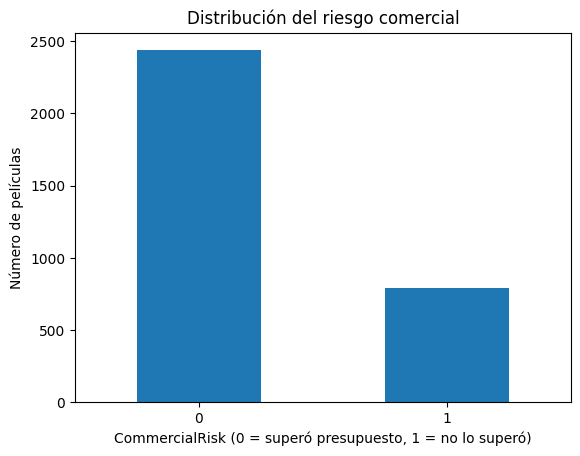

In [ ]:
df_model["CommercialRisk"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución del riesgo comercial")
plt.xlabel("CommercialRisk (0 = superó presupuesto, 1 = no lo superó)")
plt.ylabel("Número de películas")
plt.xticks(rotation=0)
plt.show()

### Distribución de variables numéricas relevantes

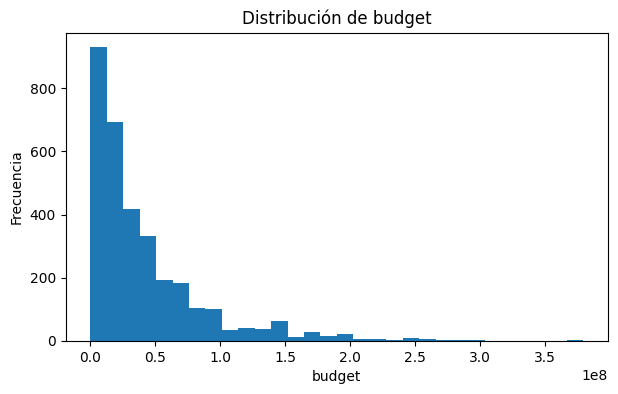

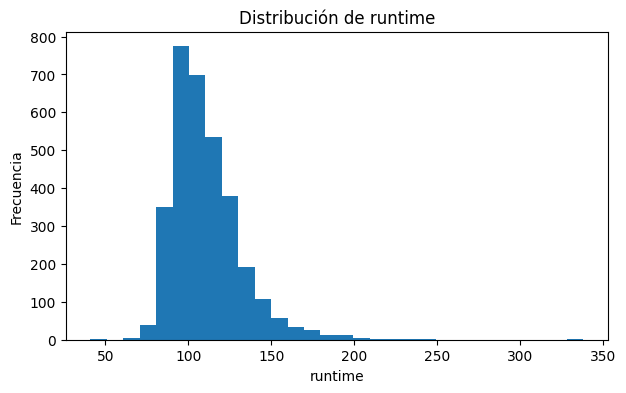

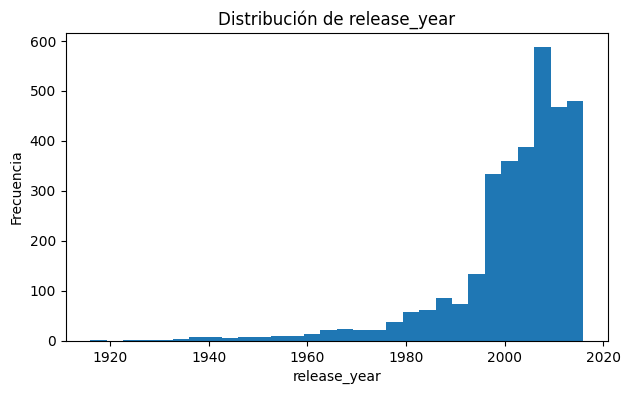

In [ ]:
for variable in ["budget", "runtime", "release_year"]:
    plt.figure(figsize=(7, 4))
    plt.hist(df_model[variable].dropna(), bins=30)
    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.show()

Los histogramas ayudan a ver qué tan concentrados o dispersos están los datos. En `budget` se observa una distribución muy sesgada por la presencia de producciones con presupuestos muy altos, mientras que `runtime` se concentra en un rango más reducido.

### Frecuencia de categorías principales

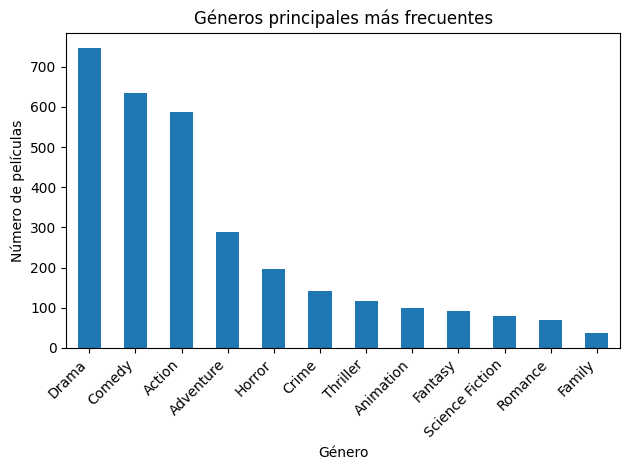

In [ ]:
df_model["primary_genre"].value_counts().head(12).plot(kind="bar")
plt.title("Géneros principales más frecuentes")
plt.xlabel("Género")
plt.ylabel("Número de películas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

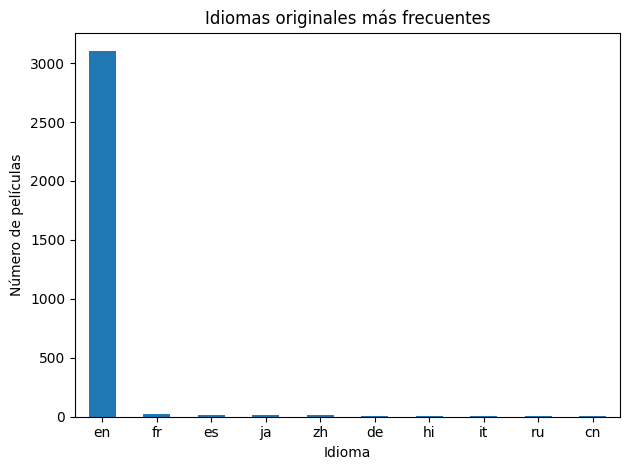

In [ ]:
df_model["original_language"].value_counts().head(10).plot(kind="bar")
plt.title("Idiomas originales más frecuentes")
plt.xlabel("Idioma")
plt.ylabel("Número de películas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Estas gráficas muestran cómo se distribuyen las películas por género e idioma.

Que una categoría aparezca más veces no significa que tenga mayor o menor riesgo; para eso es necesario comparar cada grupo directamente contra `CommercialRisk`.

### Comparación 1: género principal y riesgo comercial

In [ ]:
generos_validos = df_model["primary_genre"].value_counts().loc[lambda s: s >= 30].index

riesgo_genero = (
    df_model[df_model["primary_genre"].isin(generos_validos)]
    .groupby("primary_genre")["CommercialRisk"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

riesgo_genero["Porcentaje_riesgo"] = (riesgo_genero["mean"] * 100).round(2)
riesgo_genero[["count", "Porcentaje_riesgo"]]

,count,Porcentaje_riesgo
primary_genre,,
Drama,747,30.25
Documentary,30,30.00
Action,588,27.21
Crime,141,25.53
Thriller,118,24.58
Comedy,634,23.66
Family,38,21.05
Adventure,288,20.49
Romance,70,20.00


Los géneros Drama y Documentary muestran las proporciones de riesgo más altas entre los grupos revisados, cerca del 30%. Action también aparece por encima del promedio.

Aun así, esto solamente muestra una asociación dentro del dataset. El resultado de una película también depende de otras variables como presupuesto, estudio, reparto o tamaño del lanzamiento.

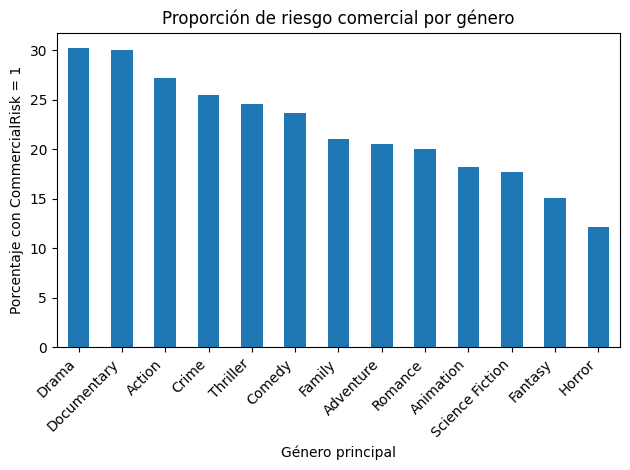

In [ ]:
riesgo_genero["Porcentaje_riesgo"].plot(kind="bar")
plt.title("Proporción de riesgo comercial por género")
plt.xlabel("Género principal")
plt.ylabel("Porcentaje con CommercialRisk = 1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

La comparación ayuda a detectar géneros donde aparece una mayor proporción de películas que no recuperaron su presupuesto. Sin embargo, no se puede concluir que el género por sí solo provoque ese resultado.

### Comparación 2: presupuesto y riesgo comercial

In [ ]:
df_model["budget_group"] = pd.qcut(df_model["budget"], q=4, duplicates="drop")

riesgo_presupuesto = df_model.groupby("budget_group", observed=False)["CommercialRisk"].agg(["mean", "count"])
riesgo_presupuesto["Porcentaje_riesgo"] = (riesgo_presupuesto["mean"] * 100).round(2)
riesgo_presupuesto[["count", "Porcentaje_riesgo"]]

,count,Porcentaje_riesgo
budget_group,,
"(0.999, 10500000.0]",812,24.75
"(10500000.0, 25000000.0]",812,29.31
"(25000000.0, 55000000.0]",820,25.24
"(55000000.0, 380000000.0]",785,18.47


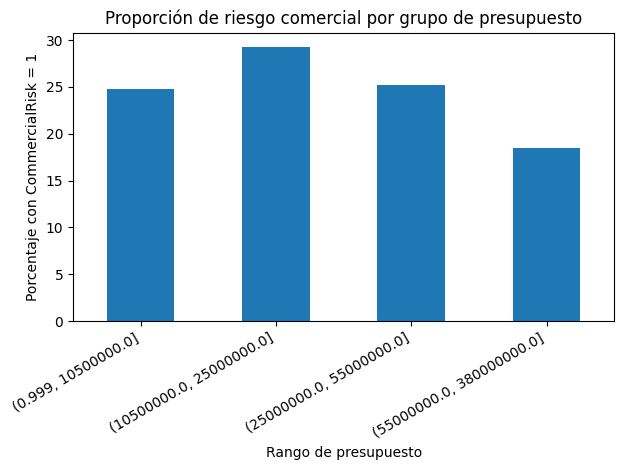

In [ ]:
riesgo_presupuesto["Porcentaje_riesgo"].plot(kind="bar")
plt.title("Proporción de riesgo comercial por grupo de presupuesto")
plt.xlabel("Rango de presupuesto")
plt.ylabel("Porcentaje con CommercialRisk = 1")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Esta comparación permite revisar si el nivel de presupuesto está relacionado con cambios en el riesgo comercial.

Debe interpretarse con cuidado porque una película con mayor presupuesto también necesita recaudar más dinero para poder superar ese mismo presupuesto.

### Comparación 3: mes de estreno y riesgo comercial

In [ ]:
riesgo_mes = df_model.dropna(subset=["release_month"]).groupby("release_month")["CommercialRisk"].agg(["mean", "count"])
riesgo_mes["Porcentaje_riesgo"] = (riesgo_mes["mean"] * 100).round(2)
riesgo_mes[["count", "Porcentaje_riesgo"]]

,count,Porcentaje_riesgo
release_month,,
1,192,30.21
2,226,27.43
3,238,23.53
4,221,25.34
5,245,20.82
6,291,16.49
7,263,16.35
8,283,27.56
9,386,34.46


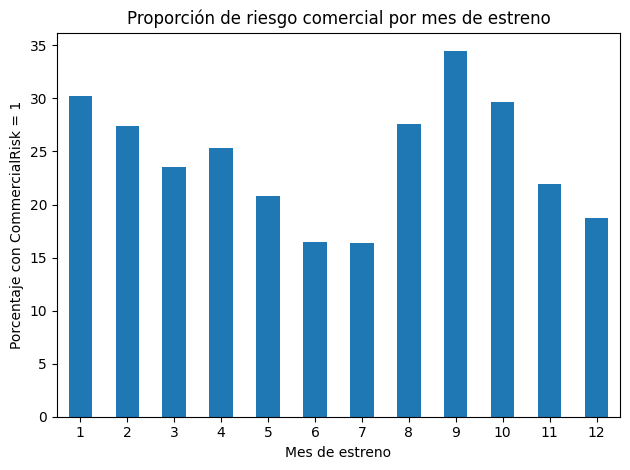

In [ ]:
riesgo_mes["Porcentaje_riesgo"].plot(kind="bar")
plt.title("Proporción de riesgo comercial por mes de estreno")
plt.xlabel("Mes de estreno")
plt.ylabel("Porcentaje con CommercialRisk = 1")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El mes de estreno muestra algunas diferencias en la proporción de riesgo. Esto podría estar relacionado con temporadas, competencia o tipo de producción, pero el mes por sí solo no explica el resultado comercial.

### Comparación 4: directores con mayor número de películas

In [ ]:
directores = df_model.dropna(subset=["director"]).groupby("director")["CommercialRisk"].agg(["mean", "count"])

directores_filtrados = directores[directores["count"] >= 5].sort_values(["mean", "count"], ascending=[False, False]).head(15)
directores_filtrados["Porcentaje_riesgo"] = (directores_filtrados["mean"] * 100).round(2)
directores_filtrados[["count", "Porcentaje_riesgo"]]

,count,Porcentaje_riesgo
director,,
William Friedkin,6,66.67
Renny Harlin,15,60.00
Brian Robbins,5,60.00
David Gordon Green,5,60.00
Neil Jordan,5,60.00
Peter Hyams,5,60.00
Brian De Palma,12,50.00
Cameron Crowe,6,50.00
Michael Mann,6,50.00


Las diferencias entre directores pueden ser interesantes, pero hay que considerar que algunos tienen pocas películas dentro del dataset.

Además, el resultado también depende de muchas otras variables, por lo que esta comparación se toma solamente como una señal exploratoria.

### Relación entre variables numéricas

In [ ]:
corr_cols = ["budget", "runtime", "release_year", "CommercialRisk"]
correlaciones = df_model[corr_cols].corr()
correlaciones.round(2)

,budget,runtime,release_year,CommercialRisk
budget,1.00,0.23,0.27,-0.11
runtime,0.23,1.00,-0.16,-0.06
release_year,0.27,-0.16,1.00,0.07
CommercialRisk,-0.11,-0.06,0.07,1.00


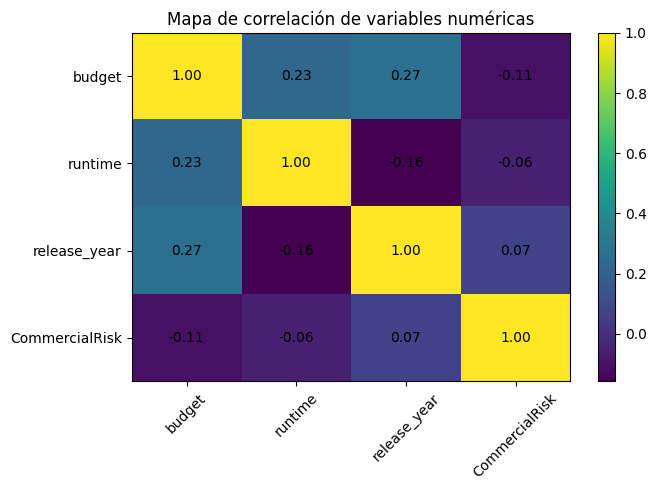

In [ ]:
plt.figure(figsize=(7, 5))
plt.imshow(correlaciones, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlaciones.columns)), correlaciones.columns, rotation=45)
plt.yticks(range(len(correlaciones.columns)), correlaciones.columns)

for i in range(len(correlaciones)):
    for j in range(len(correlaciones)):
        plt.text(j, i, f"{correlaciones.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Mapa de correlación de variables numéricas")
plt.tight_layout()
plt.show()

La matriz de correlación muestra que ninguna de las variables numéricas analizadas tiene una relación lineal fuerte con `CommercialRisk`.

`budget` presenta una correlación de **-0.11**, `runtime` de **-0.06** y `release_year` de **0.07**. Esto sugiere que el riesgo comercial probablemente depende de una combinación de variables y no de una sola característica numérica.

### Identificación visual de posibles valores atípicos

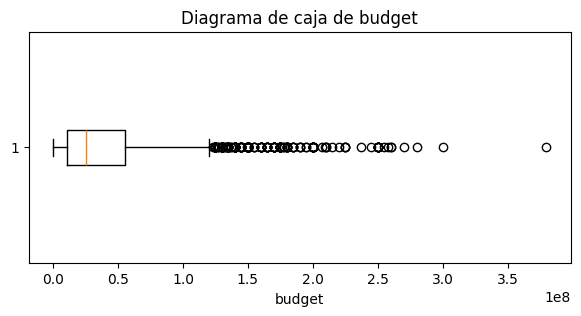

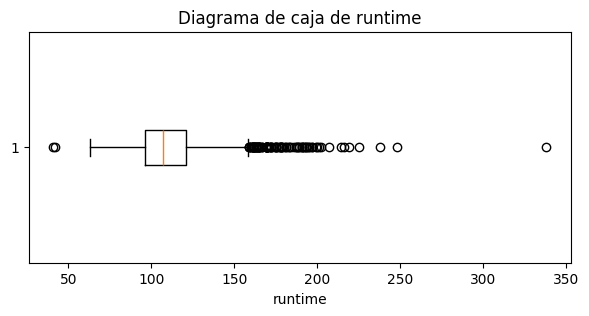

In [ ]:
for variable in ["budget", "runtime"]:
    plt.figure(figsize=(7, 3))
    plt.boxplot(df_model[variable].dropna(), vert=False)
    plt.title(f"Diagrama de caja de {variable}")
    plt.xlabel(variable)
    plt.show()

Los boxplots muestran varios valores extremos en `budget` y `runtime`.

En presupuesto esto es esperable porque existen grandes producciones muy alejadas del presupuesto típico. Por esa razón no se eliminan automáticamente: primero se conserva la información y el pipeline se encarga de aplicar transformaciones que reduzcan su impacto.

### Perfiles iniciales con mayor proporción de riesgo

In [ ]:
perfiles = []

for genero, row in riesgo_genero.iterrows():
    perfiles.append([f"Género: {genero}", int(row["count"]), round(row["mean"] * 100, 2)])

idiomas_riesgo = df_model.groupby("original_language")["CommercialRisk"].agg(["mean", "count"])
idiomas_riesgo = idiomas_riesgo[idiomas_riesgo["count"] >= 30]

for idioma, row in idiomas_riesgo.iterrows():
    perfiles.append([f"Idioma: {idioma}", int(row["count"]), round(row["mean"] * 100, 2)])

perfiles_df = pd.DataFrame(perfiles, columns=["Perfil", "Películas", "Porcentaje de riesgo"]).sort_values(["Porcentaje de riesgo", "Películas"], ascending=[False, False]).head(12)
perfiles_df

,Perfil,Películas,Porcentaje de riesgo
0,Género: Drama,747,30.25
1,Género: Documentary,30,30.00
2,Género: Action,588,27.21
3,Género: Crime,141,25.53
4,Género: Thriller,118,24.58
13,Idioma: en,3102,24.24
5,Género: Comedy,634,23.66
6,Género: Family,38,21.05
7,Género: Adventure,288,20.49
8,Género: Romance,70,20.00


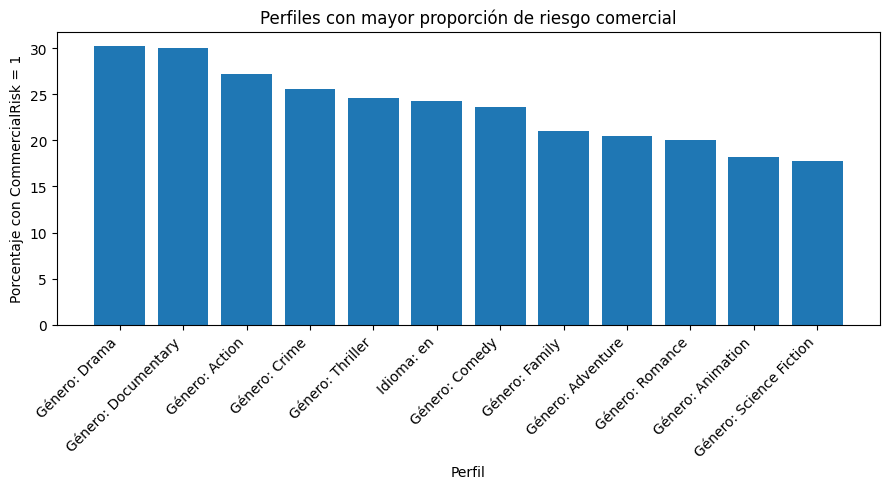

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(perfiles_df["Perfil"], perfiles_df["Porcentaje de riesgo"])
plt.title("Perfiles con mayor proporción de riesgo comercial")
plt.xlabel("Perfil")
plt.ylabel("Porcentaje con CommercialRisk = 1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Estas comparaciones ayudan a encontrar perfiles que parecen presentar más riesgo dentro del dataset y sirven como punto de partida para seleccionar variables.

De todas formas, los patrones observados aquí todavía deben comprobarse con modelos y conjuntos separados de entrenamiento y validación.

## 9. Revisión del posible desbalance de clases

Se revisa nuevamente la proporción de las dos clases para saber si existe un desbalance que pueda hacer que algunas métricas se vean mejores de lo que realmente son.

In [ ]:
conteo_clases = df_model["CommercialRisk"].value_counts().sort_index()
proporcion_clases = df_model["CommercialRisk"].value_counts(normalize=True).sort_index().mul(100).round(2)

balance_final = pd.DataFrame({"Cantidad": conteo_clases, "Porcentaje": proporcion_clases})
balance_final.index = ["0 - Superó presupuesto", "1 - No superó presupuesto"]
balance_final

,Cantidad,Porcentaje
0 - Superó presupuesto,2438,75.5
1 - No superó presupuesto,791,24.5


In [ ]:
clase_mayoritaria = conteo_clases.idxmax()
accuracy_ingenua = conteo_clases.max() / conteo_clases.sum() * 100
print(f"Si un modelo predijera siempre la clase mayoritaria ({clase_mayoritaria}), obtendría aproximadamente {accuracy_ingenua:.2f}% de accuracy.")

Si un modelo predijera siempre la clase mayoritaria (0), obtendría aproximadamente 75.50% de accuracy.


### ¿Por qué una accuracy alta puede ser engañosa?

Si una clase aparece mucho más que la otra, un modelo podría obtener una `accuracy` alta simplemente prediciendo casi siempre la clase mayoritaria.

Por eso, en este proyecto la accuracy se tomará como referencia, pero no será suficiente para decidir qué modelo funciona mejor.

### Métricas necesarias

Además de `accuracy`, se usarán:

- **Precision:** de las películas marcadas como riesgo, cuántas realmente eran de riesgo.
- **Recall:** de todas las películas que realmente eran de riesgo, cuántas logró detectar el modelo.
- **F1-score:** equilibrio entre precision y recall.
- **ROC-AUC:** capacidad general del modelo para separar ambas clases.
- **Matriz de confusión:** permite ver directamente verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

Para este proyecto el `recall` tiene especial importancia porque interesa reducir los falsos negativos.

### Implicación de los falsos negativos

Un **falso negativo** ocurre cuando el modelo predice `CommercialRisk = 0`, pero la película realmente pertenece a `CommercialRisk = 1`.

Este error es importante porque haría que un proyecto con riesgo comercial pareciera más seguro de lo que realmente es. Por eso se buscará aumentar el recall sin perder por completo la precision.

### Por qué no es obligatorio aplicar remuestreo en esta fase

En este avance primero se busca tener una línea base clara y reproducible usando la distribución original de los datos.

Antes de aplicar técnicas como oversampling, undersampling o SMOTE conviene observar qué tan mal afecta el desbalance a los modelos iniciales. Después, si es necesario, estas técnicas pueden compararse en la siguiente fase.

### Conclusión del análisis de desbalance

El desbalance de `CommercialRisk` sí debe tomarse en cuenta al evaluar los modelos.

La `accuracy` se usará solamente como referencia. Para decidir si el modelo realmente es útil se dará más importancia a `recall`, `precision`, F1-score y a la matriz de confusión, especialmente por el costo de los falsos negativos.

## 10. Identificación de posibles fugas de información

Antes de entrenar los modelos se revisan las variables que podrían revelar información del resultado o que solamente estarían disponibles después del estreno.

El objetivo es que el modelo utilice únicamente datos que tendría disponibles en una situación real de predicción.

In [ ]:
fugas = pd.DataFrame([
    [
        "revenue",
        "Se conoce después de que la película genera ingresos en taquilla.",
        "No",
        "Muy alto. Se utiliza directamente para construir CommercialRisk.",
        "Eliminar como predictora",
        "CommercialRisk se define comparando revenue con budget, por lo que utilizar revenue permitiría al modelo conocer prácticamente la respuesta."
    ],
    [
        "popularity",
        "El valor de popularidad de TMDB cambia con la atención e interacción recibida por la película.",
        "No de forma equivalente antes del estreno",
        "Alto. Puede reflejar el desempeño y atención obtenidos después del lanzamiento.",
        "Eliminar como predictora",
        "El proyecto busca estimar riesgo con información disponible antes o alrededor del estreno."
    ],
    [
        "vote_average",
        "Se genera a partir de las calificaciones de usuarios después de que la película está disponible.",
        "No",
        "Alto. Puede reflejar la recepción posterior de la película.",
        "Eliminar como predictora",
        "No sería una característica disponible al realizar una predicción previa al desempeño comercial."
    ],
    [
        "vote_count",
        "Se genera conforme los usuarios califican la película después de su lanzamiento.",
        "No",
        "Alto. Una gran cantidad de votos puede estar relacionada con la exposición y popularidad posterior.",
        "Eliminar como predictora",
        "Utilizarla permitiría introducir información posterior al estreno."
    ],
    [
        "CommercialRisk",
        "Se genera a partir de budget y revenue.",
        "Es la variable que se desea predecir",
        "Total si se utilizara como entrada.",
        "Utilizar únicamente como objetivo",
        "Es la variable objetivo y nunca debe incluirse dentro de X."
    ]
],
columns=[
    "Variable",
    "Cuándo se genera",
    "Disponible al predecir",
    "Riesgo de inflar métricas",
    "Decisión",
    "Justificación"
])

display(fugas)

,Variable,Cuándo se genera,Disponible al predecir,Riesgo de inflar métricas,Decisión,Justificación
0,revenue,Se conoce después de que la película genera in...,No,Muy alto. Se utiliza directamente para constru...,Eliminar como predictora,CommercialRisk se define comparando revenue co...
1,popularity,El valor de popularidad de TMDB cambia con la ...,No de forma equivalente antes del estreno,Alto. Puede reflejar el desempeño y atención o...,Eliminar como predictora,El proyecto busca estimar riesgo con informaci...
2,vote_average,Se genera a partir de las calificaciones de us...,No,Alto. Puede reflejar la recepción posterior de...,Eliminar como predictora,No sería una característica disponible al real...
3,vote_count,Se genera conforme los usuarios califican la p...,No,Alto. Una gran cantidad de votos puede estar r...,Eliminar como predictora,Utilizarla permitiría introducir información p...
4,CommercialRisk,Se genera a partir de budget y revenue.,Es la variable que se desea predecir,Total si se utilizara como entrada.,Utilizar únicamente como objetivo,Es la variable objetivo y nunca debe incluirse...


### Variables disponibles para la predicción

Variables como `budget`, `runtime`, `genres`, `original_language`, `production_companies`, `release_date`, `cast` y `crew` contienen información que puede conocerse antes o alrededor del estreno de una película.

A partir de algunas de ellas también se generaron variables como `primary_genre`, `production_company`, `director`, `writer`, `lead_actor`, `release_year` y `release_month`.

Estas variables pueden conservarse como posibles predictoras porque no revelan directamente el resultado de taquilla que se busca estimar.

Es importante aclarar que `budget` forma parte de la definición de `CommercialRisk`, pero no se considera fuga de información. A diferencia de `revenue`, el presupuesto de producción es información que puede conocerse antes del estreno y, por lo tanto, puede utilizarse como predictor.

### Variables excluidas por otras razones

No todas las variables eliminadas representan fuga de información.

`id`, `title` y `original_title` se excluyen principalmente por funcionar como identificadores o presentar una cardinalidad muy alta.

Variables como `overview`, `tagline` y `keywords` también se dejan fuera de la línea base, pero debido a que requerirían técnicas adicionales de procesamiento de texto y no porque representen necesariamente una fuga de información.

Por lo tanto, se diferencia entre variables eliminadas para evitar fuga de información y variables eliminadas por razones de complejidad, cardinalidad o poca utilidad para la línea base.

In [ ]:
variables_con_fuga = [
    "revenue",
    "popularity",
    "vote_average",
    "vote_count"
]

variables_con_fuga

['revenue', 'popularity', 'vote_average', 'vote_count']

### Separación entre variables con fuga y variable objetivo

In [ ]:
variables_con_fuga = [
    "revenue",
    "popularity",
    "vote_average",
    "vote_count"
]

variable_objetivo = "CommercialRisk"

print("Variables con posible fuga:")
for variable in variables_con_fuga:
    print("-", variable)

print("\nVariable objetivo:", variable_objetivo)

Variables con posible fuga:
- revenue
- popularity
- vote_average
- vote_count

Variable objetivo: CommercialRisk


Se distinguen las variables que representan un posible riesgo de fuga de información de la variable objetivo del proyecto.

`revenue`, `popularity`, `vote_average` y `vote_count` se consideran variables con posible fuga porque contienen información posterior al estreno o relacionada directamente con el desempeño comercial.

Por otro lado, `CommercialRisk` no se considera una fuga de información, ya que corresponde a la variable objetivo que el modelo busca predecir. Por esta razón, se mantiene separada de las variables predictoras y solo se utilizará como `y` durante el modelado.

In [ ]:
variables_predictoras = [
    "budget",
    "runtime",
    "original_language",
    "primary_genre",
    "production_company",
    "director",
    "writer",
    "lead_actor",
    "release_year",
    "release_month"
]

print("Variables seleccionadas para el modelado:")
for variable in variables_predictoras:
    print("-", variable)

Variables seleccionadas para el modelado:
- budget
- runtime
- original_language
- primary_genre
- production_company
- director
- writer
- lead_actor
- release_year
- release_month


### Conclusión sobre fuga de información

Sí existen variables que podrían causar fuga de información.

La más importante es `revenue`, porque se utiliza directamente para construir `CommercialRisk`. También se excluyen variables como `popularity`, `vote_average` y `vote_count` porque pueden contener información posterior al estreno.

Con estas exclusiones, el modelo queda limitado a variables que sí podrían conocerse antes o alrededor del lanzamiento.

## 11. Separación de variables predictoras y variable objetivo

Se separan las variables de entrada (`X`) de la variable objetivo (`y`).

En `X` quedan únicamente las características seleccionadas para realizar las predicciones, mientras que `y` contiene `CommercialRisk`.

### Codificación de la variable objetivo

| Valor original | Codificación |
|---|---:|
| Superó su presupuesto en taquilla | 0 |
| No superó su presupuesto en taquilla | 1 |

La **clase positiva corresponde a `CommercialRisk = 1`**, ya que representa el caso de interés que se busca detectar: una película con riesgo de no superar su presupuesto de producción mediante la taquilla reportada.

In [ ]:
variables_predictoras = [
    "budget",
    "runtime",
    "original_language",
    "primary_genre",
    "production_company",
    "director",
    "writer",
    "lead_actor",
    "release_year",
    "release_month"
]

X = df_model[variables_predictoras].copy()
y = df_model["CommercialRisk"].copy()

In [ ]:
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nDistribución de la variable objetivo:")
print(y.value_counts().sort_index())

print("\nProporción de clases:")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

Dimensiones de X: (3229, 10)
Dimensiones de y: (3229,)

Distribución de la variable objetivo:
CommercialRisk
0    2438
1     791
Name: count, dtype: int64

Proporción de clases:
CommercialRisk
0    75.5
1    24.5
Name: proportion, dtype: float64


In [ ]:
print("Variables predictoras utilizadas:")

for variable in X.columns:
    print("-", variable)

Variables predictoras utilizadas:
- budget
- runtime
- original_language
- primary_genre
- production_company
- director
- writer
- lead_actor
- release_year
- release_month


`X` contiene únicamente las variables seleccionadas para el modelado y `y` contiene la clasificación de riesgo.

Las variables que funcionan como identificadores, presentan fuga de información o no estarían disponibles al momento de predecir quedan fuera del conjunto de entrada.

In [ ]:
variables_prohibidas = [
    "revenue",
    "popularity",
    "vote_average",
    "vote_count",
    "CommercialRisk"
]

for variable in variables_prohibidas:
    print(
        variable,
        "está en X:" if variable in X.columns else "NO está en X"
    )

revenue NO está en X
popularity NO está en X
vote_average NO está en X
vote_count NO está en X
CommercialRisk NO está en X


### Conclusión de la separación

La separación deja claramente definido qué información utilizará el modelo y qué variable intentará predecir.

Esto también facilita que las siguientes etapas de partición, preprocesamiento y entrenamiento se realicen de forma reproducible.

## 12. Estrategia de partición de los datos

Los datos se dividen en tres conjuntos:

- **70% entrenamiento**
- **15% validación**
- **15% prueba**

Se utiliza `random_state = 42` para poder repetir la misma división y `stratify` para conservar aproximadamente la misma proporción de clases en los tres conjuntos.

El conjunto de prueba se deja completamente separado hasta la evaluación final.

In [ ]:
from sklearn.model_selection import train_test_split

# Primera división: 70% entrenamiento y 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Segunda división: 15% validación y 15% prueba
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [ ]:
print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (2260, 10) (2260,)
Validación: (484, 10) (484,)
Prueba: (485, 10) (485,)


### Tamaño de las particiones

La división produjo **2,260 películas para entrenamiento**, **484 para validación** y **485 para prueba**, valores muy cercanos a la proporción planeada de 70/15/15.

In [ ]:
def mostrar_distribucion(nombre, y_data):
    distribucion = (
        y_data.value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    print(nombre)
    print(distribucion)
    print()

mostrar_distribucion("Entrenamiento", y_train)
mostrar_distribucion("Validación", y_val)
mostrar_distribucion("Prueba", y_test)

Entrenamiento
CommercialRisk
0    75.49
1    24.51
Name: proportion, dtype: float64

Validación
CommercialRisk
0    75.62
1    24.38
Name: proportion, dtype: float64

Prueba
CommercialRisk
0    75.46
1    24.54
Name: proportion, dtype: float64



### Verificación de la estratificación

La proporción de las clases se mantiene prácticamente igual en entrenamiento, validación y prueba.

Esto confirma que la división estratificada funcionó y evita que uno de los conjuntos quede con una distribución muy diferente a los demás.

### Parámetros utilizados para la partición

| Parámetro | Valor utilizado |
|---|---|
| Proporción de entrenamiento | 70% |
| Proporción de validación | 15% |
| Proporción de prueba | 15% |
| Semilla | 42 |
| Método de estratificación | `stratify = y` y `stratify = y_temp` |

### Función de cada conjunto

El conjunto de **entrenamiento** se utiliza para ajustar los modelos.

El conjunto de **validación** sirve para comparar modelos, revisar métricas y tomar decisiones como el umbral o los hiperparámetros.

El conjunto de **prueba** queda reservado para medir el desempeño final una sola vez después de seleccionar la mejor configuración.

### Preprocesamiento después de la partición

El preprocesamiento se ajusta después de separar los datos.

Esto es importante porque las medianas, categorías, medias y desviaciones utilizadas por el pipeline deben aprenderse solamente con el conjunto de entrenamiento. Así se evita que información de validación o prueba se filtre al modelo.

### Conclusión de la estrategia de partición

La partición 70/15/15 permite separar correctamente el entrenamiento, la selección del modelo y la evaluación final.

Además, la semilla fija y la estratificación hacen que el experimento sea reproducible y que las clases mantengan proporciones similares en los tres conjuntos.

## 13. Pipeline de preprocesamiento

El preprocesamiento se organiza con `Pipeline` y `ColumnTransformer` para que cada tipo de variable reciba el tratamiento que necesita.

Las variables numéricas se imputan y escalan, `budget` también recibe una transformación logarítmica y las variables categóricas se imputan y codifican con One-Hot Encoding.

De esta forma todo el proceso queda dentro de una sola estructura reproducible.

In [ ]:
columnas_numericas = [
    "runtime",
    "release_year"
]

columnas_budget = [
    "budget"
]

columnas_categoricas = [
    "original_language",
    "primary_genre",
    "production_company",
    "director",
    "writer",
    "lead_actor",
    "release_month"
]

print("Numéricas:", columnas_numericas)
print("Budget:", columnas_budget)
print("Categóricas:", columnas_categoricas)

Numéricas: ['runtime', 'release_year']
Budget: ['budget']
Categóricas: ['original_language', 'primary_genre', 'production_company', 'director', 'writer', 'lead_actor', 'release_month']


### Separación de variables

`runtime` y `release_year` se consideran variables numéricas y se procesarán mediante imputación y estandarización.

`budget` también es numérica, pero recibirá un tratamiento adicional mediante una transformación logarítmica. Esta decisión se debe a que durante el análisis exploratorio se observó una distribución muy sesgada hacia presupuestos altos y varios valores extremos que pueden ser películas válidas.

Las demás variables seleccionadas son categóricas. `release_month`, aunque se almacena mediante números del 1 al 12, se tratará como categórica porque esos valores representan meses y no una magnitud continua.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)

Runtime y release_year

In [ ]:
pipeline_numerico = Pipeline(steps=[
    (
        "imputacion",
        SimpleImputer(strategy="median")
    ),
    (
        "escalamiento",
        StandardScaler()
    )
])

Budget

In [ ]:
pipeline_budget = Pipeline(steps=[
    (
        "imputacion",
        SimpleImputer(strategy="median")
    ),
    (
        "logaritmo",
        FunctionTransformer(np.log1p)
    ),
    (
        "escalamiento",
        StandardScaler()
    )
])

### Tratamiento de variables numéricas

Los faltantes numéricos se imputan con la **mediana**, porque es menos sensible a valores extremos.

Después se utiliza `StandardScaler` para llevar las variables a una escala comparable. En `budget` también se aplica `log1p` para reducir el efecto de su fuerte asimetría.

In [ ]:
pipeline_categorico = Pipeline(steps=[
    (
        "imputacion",
        SimpleImputer(
            strategy="constant",
            fill_value="Unknown"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            min_frequency=5
        )
    )
])

### Tratamiento de variables categóricas

Los valores faltantes se reemplazan por `Unknown` y después se aplica `OneHotEncoder`.

Se utiliza `handle_unknown="ignore"` para que categorías nuevas no provoquen errores, y `min_frequency=5` para agrupar categorías poco frecuentes y controlar la cantidad de variables generadas.

In [ ]:
preprocesador = ColumnTransformer(
    transformers=[
        (
            "budget",
            pipeline_budget,
            columnas_budget
        ),
        (
            "numericas",
            pipeline_numerico,
            columnas_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            columnas_categoricas
        )
    ]
)

preprocesador

ColumnTransformer(transformers=[('budget',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(strategy='median')),
                                                 ('logaritmo',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('escalamiento',
                                                  StandardScaler())]),
                                 ['budget']),
                                ('numericas',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(strategy='median')),
                                                 ('escalamiento',
                                                  StandardScaler())]),
                                 ['runtime', 'release_year']),
                                ('categoricas',
                                 Pipeline(steps=[('imputacion',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                min_frequency=5))]),
                                 ['original_language', 'primary_genre',
                                  'production_company', 'director', 'writer',
                                  'lead_actor', 'release_month'])])

### Integración mediante ColumnTransformer

`ColumnTransformer` permite aplicar diferentes transformaciones a cada grupo de variables dentro del mismo flujo.

Esto evita hacer pasos manuales por separado y ayuda a que exactamente el mismo preprocesamiento pueda reutilizarse después con validación, prueba o datos nuevos.

In [ ]:
X_train_procesado = preprocesador.fit_transform(X_train)

X_val_procesado = preprocesador.transform(X_val)
X_test_procesado = preprocesador.transform(X_test)

print(
    "Entrenamiento:",
    X_train_procesado.shape
)

print(
    "Validación:",
    X_val_procesado.shape
)

print(
    "Prueba:",
    X_test_procesado.shape
)

Entrenamiento: (2260, 352)
Validación: (484, 352)
Prueba: (485, 352)


### Resultado de la transformación

Las 10 variables predictoras originales se convierten en **352 características** después del preprocesamiento.

La mayor parte del aumento viene del One-Hot Encoding aplicado a variables categóricas como género, director, actor principal y productora.

### Ajuste del preprocesamiento

El pipeline se ajusta únicamente con `X_train` usando `fit_transform`.

Después, validación y prueba solamente pasan por `transform`. Así, las estadísticas y categorías aprendidas provienen exclusivamente del conjunto de entrenamiento y se evita fuga de información.

In [ ]:
print(
    "Mismo número de variables transformadas:",
    X_train_procesado.shape[1]
    == X_val_procesado.shape[1]
    == X_test_procesado.shape[1]
)

Mismo número de variables transformadas: True


La verificación confirma que entrenamiento, validación y prueba terminan con el mismo número de características.

Esto es necesario para que los modelos puedan entrenarse con un conjunto y recibir después datos con exactamente la misma estructura.

### Resumen de transformaciones

| Variables | Tratamiento |
|---|---|
| `budget` | Imputación con mediana → transformación `log1p` → estandarización |
| `runtime`, `release_year` | Imputación con mediana → estandarización |
| `original_language`, `primary_genre`, `production_company`, `director`, `writer`, `lead_actor`, `release_month` | Imputación con `Unknown` → One-Hot Encoding |
| Categorías desconocidas | Se ignoran mediante `handle_unknown="ignore"` |
| Categorías muy poco frecuentes | Se agrupan mediante `min_frequency=5` |

### Conclusión del preprocesamiento

El pipeline deja todo el preprocesamiento organizado y reproducible.

Las variables numéricas y categóricas reciben tratamientos distintos, se controla la alta cardinalidad y, lo más importante, todo se ajusta solamente con entrenamiento para evitar fuga de información.

## 14. Modelo baseline

Como primera referencia se utiliza un `DummyClassifier` con `strategy="most_frequent"`.

Este modelo siempre predice la clase más común. No se espera que sea útil por sí mismo; su función es mostrar el nivel mínimo que los demás modelos deberían superar.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

Configuracion Baseline

In [ ]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

baseline.fit(X_train, y_train)

y_val_baseline = baseline.predict(X_val)

In [ ]:
accuracy_baseline = accuracy_score(y_val, y_val_baseline)
precision_baseline = precision_score(
    y_val,
    y_val_baseline,
    zero_division=0
)
recall_baseline = recall_score(
    y_val,
    y_val_baseline,
    zero_division=0
)
f1_baseline = f1_score(
    y_val,
    y_val_baseline,
    zero_division=0
)

print("Accuracy:", round(accuracy_baseline, 4))
print("Precision:", round(precision_baseline, 4))
print("Recall:", round(recall_baseline, 4))
print("F1-score:", round(f1_baseline, 4))

Accuracy: 0.7562
Precision: 0.0
Recall: 0.0
F1-score: 0.0


### Resultados del baseline

El baseline obtiene una `accuracy` relativamente alta porque predice siempre la clase mayoritaria.

El problema es que no detecta ninguna película con `CommercialRisk = 1`, por lo que su `recall` es 0. Esto confirma por qué la accuracy sola puede dar una impresión equivocada del desempeño.

Matriz de confusión

In [ ]:
matriz_baseline = confusion_matrix(
    y_val,
    y_val_baseline
)

print(matriz_baseline)

[[366   0]
 [118   0]]


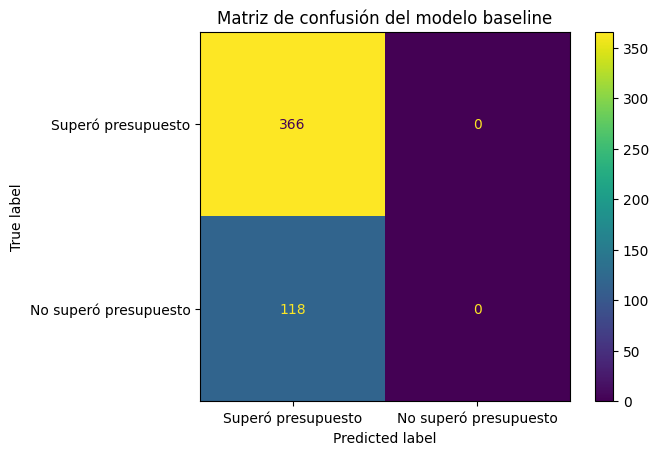

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=matriz_baseline,
    display_labels=[
        "Superó presupuesto",
        "No superó presupuesto"
    ]
).plot()

plt.title("Matriz de confusión del modelo baseline")
plt.show()

### Interpretación de la matriz de confusión

El baseline clasifica correctamente las **366 películas de clase 0**, pero falla en las **118 películas con riesgo comercial**.

En otras palabras, consigue una accuracy aceptable solamente porque la clase 0 es la más frecuente, pero no cumple con el objetivo principal del proyecto.

### Configuración del baseline

| Parámetro | Valor utilizado |
|---|---|
| Modelo | `DummyClassifier` |
| Estrategia | `most_frequent` |
| Datos de entrenamiento | `X_train`, `y_train` |
| Conjunto de evaluación | Validación |
| Clase positiva | `CommercialRisk = 1` |
| Métricas | Accuracy, Precision, Recall, F1-score y matriz de confusión |

### Conclusión del modelo baseline

El baseline sirve como punto de comparación, pero no como una solución útil.

Aunque alcanza una accuracy cercana al porcentaje de la clase mayoritaria, su recall es 0 y no identifica ningún caso de riesgo comercial. Los siguientes modelos necesitan mejorar claramente este resultado.

## 15. Entrenamiento de modelos iniciales

Además del baseline se entrenan dos modelos sencillos para tener una primera comparación real:

- **Regresión Logística**
- **Árbol de Decisión**

La Regresión Logística funciona como una referencia lineal e interpretable, mientras que el Árbol de Decisión puede representar relaciones no lineales entre las variables.

En esta fase se utilizan configuraciones iniciales; el ajuste de hiperparámetros se deja para la siguiente etapa.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone

In [ ]:
modelo_logistica = Pipeline(steps=[
    (
        "preprocesamiento",
        clone(preprocesador)
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

modelo_logistica.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('budget',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('logaritmo',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('escalamiento',
                                                                   StandardScaler())]),
                                                  ['budget']),
                                                 ('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalamiento',
                                                                   StandardScal...
                                                  ['runtime', 'release_year']),
                                                 ('categoricas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=5))]),
                                                  ['original_language',
                                                   'primary_genre',
                                                   'production_company',
                                                   'director', 'writer',
                                                   'lead_actor',
                                                   'release_month'])])),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

### Regresión logística

Se utiliza como primer modelo porque es relativamente simple, interpretable y funciona bien como línea base para clasificación.

Se establece `max_iter=1000` para permitir que el algoritmo tenga suficientes iteraciones para converger.

In [ ]:
y_val_logistica = modelo_logistica.predict(X_val)

print("Modelo de regresión logística entrenado correctamente.")
print("Predicciones de validación:", len(y_val_logistica))

Modelo de regresión logística entrenado correctamente.
Predicciones de validación: 484


In [ ]:
modelo_arbol = Pipeline(steps=[
    (
        "preprocesamiento",
        clone(preprocesador)
    ),
    (
        "modelo",
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        )
    )
])

modelo_arbol.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('budget',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('logaritmo',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('escalamiento',
                                                                   StandardScaler())]),
                                                  ['budget']),
                                                 ('numericas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalamiento',
                                                                   StandardScal...
                                                  ['runtime', 'release_year']),
                                                 ('categoricas',
                                                  Pipeline(steps=[('imputacion',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=5))]),
                                                  ['original_language',
                                                   'primary_genre',
                                                   'production_company',
                                                   'director', 'writer',
                                                   'lead_actor',
                                                   'release_month'])])),
                ('modelo',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

### Árbol de decisión

El Árbol de Decisión se utiliza como una alternativa no lineal.

A diferencia de la Regresión Logística, puede capturar interacciones y divisiones más específicas entre variables. Se limita su profundidad para evitar que el modelo se vuelva demasiado complejo desde esta primera comparación.

In [ ]:
y_val_arbol = modelo_arbol.predict(X_val)

print("Modelo de árbol de decisión entrenado correctamente.")
print("Predicciones de validación:", len(y_val_arbol))

Modelo de árbol de decisión entrenado correctamente.
Predicciones de validación: 484


In [ ]:
print("Datos de entrenamiento:", len(y_train))
print("Datos de validación:", len(y_val))

print("\nPredicciones:")
print("Baseline:", len(y_val_baseline))
print("Regresión logística:", len(y_val_logistica))
print("Árbol de decisión:", len(y_val_arbol))

Datos de entrenamiento: 2260
Datos de validación: 484

Predicciones:
Baseline: 484
Regresión logística: 484
Árbol de decisión: 484


### Verificación del entrenamiento

Los tres modelos generan predicciones sobre las mismas **484 películas del conjunto de validación**.

Esto permite compararlos bajo exactamente las mismas condiciones.

### Configuración de los modelos

| Modelo | Función dentro de la comparación | Configuración inicial |
|---|---|---|
| `DummyClassifier` | Referencia trivial | `strategy="most_frequent"` |
| Regresión Logística | Línea base interpretable | `max_iter=1000`, `random_state=42` |
| Árbol de Decisión | Alternativa no lineal | `max_depth=5`, `random_state=42` |

Todos los modelos utilizan la misma división de datos. Los dos modelos de aprendizaje automático utilizan el mismo pipeline de preprocesamiento definido anteriormente.

### Alcance de la comparación inicial

Todavía no se realiza una búsqueda extensa de hiperparámetros.

La intención de esta fase es comparar configuraciones iniciales razonables y establecer un punto de referencia antes de invertir tiempo en optimización.

### Conclusión del entrenamiento inicial

Se entrenaron correctamente el baseline, la Regresión Logística y el Árbol de Decisión usando los mismos conjuntos de entrenamiento y validación.

Con esto ya existe una base suficiente para comparar métricas y decidir qué modelo vale la pena seguir mejorando.

## 16. Evaluación de los modelos

Los tres modelos se evalúan únicamente con el conjunto de validación.

La clase positiva es `CommercialRisk = 1`, por lo que interesa especialmente revisar cuántas películas con riesgo logra detectar cada modelo y cuántos falsos negativos deja.

### Métricas utilizadas

- **Accuracy:** porcentaje total de predicciones correctas.
- **Precision:** qué porcentaje de las predicciones de riesgo realmente eran riesgo.
- **Recall:** qué porcentaje de las películas con riesgo logró detectar el modelo.
- **F1-score:** combina precision y recall en una sola medida.
- **ROC-AUC:** mide qué tan bien separa el modelo ambas clases usando sus probabilidades.
- **Matriz de confusión:** muestra directamente los aciertos y errores por clase.

En este proyecto el `recall` tiene especial importancia porque los falsos negativos son el error más delicado.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Probabilidad de pertenecer a la clase positiva (CommercialRisk = 1)

y_prob_baseline = baseline.predict_proba(X_val)[:, 1]

y_prob_logistica = modelo_logistica.predict_proba(X_val)[:, 1]

y_prob_arbol = modelo_arbol.predict_proba(X_val)[:, 1]

In [ ]:
def evaluar_modelo(nombre, y_real, y_pred, y_prob):
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_real, y_pred),
        "Precision": precision_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_real,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_real,
            y_prob
        )
    }

In [ ]:
resultados = [
    evaluar_modelo(
        "DummyClassifier",
        y_val,
        y_val_baseline,
        y_prob_baseline
    ),

    evaluar_modelo(
        "Regresión logística",
        y_val,
        y_val_logistica,
        y_prob_logistica
    ),

    evaluar_modelo(
        "Árbol de decisión",
        y_val,
        y_val_arbol,
        y_prob_arbol
    )
]

tabla_resultados = pd.DataFrame(resultados)

tabla_resultados

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,DummyClassifier,0.756198,0.000000,0.000000,0.000000,0.500000
1,Regresión logística,0.758264,0.571429,0.033898,0.064000,0.577035
2,Árbol de decisión,0.754132,0.333333,0.008475,0.016529,0.557551


In [ ]:
tabla_resultados_redondeada = tabla_resultados.copy()

columnas_metricas = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

tabla_resultados_redondeada[columnas_metricas] = (
    tabla_resultados_redondeada[columnas_metricas]
    .round(4)
)

tabla_resultados_redondeada

,Modelo,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,DummyClassifier,0.7562,0.0000,0.0000,0.0000,0.5000
1,Regresión logística,0.7583,0.5714,0.0339,0.0640,0.5770
2,Árbol de decisión,0.7541,0.3333,0.0085,0.0165,0.5576


### Comparación de modelos, configuración y resultados

| Modelo | Configuración | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---|---:|---:|---:|---:|---:|
| **DummyClassifier** | `strategy="most_frequent"` | 0.7562 | 0.0000 | 0.0000 | 0.0000 | 0.5000 |
| **Regresión Logística** | `max_iter=1000`, `random_state=42` | 0.7583 | 0.5714 | 0.0339 | 0.0640 | 0.5770 |
| **Árbol de Decisión** | `max_depth=5`, `random_state=42` | 0.7541 | 0.3333 | 0.0085 | 0.0165 | 0.5576 |

Esta tabla junta en un solo lugar la configuración inicial y las métricas principales de cada modelo para que la comparación sea más clara.

### Comparación inicial de métricas

Ninguno de los modelos iniciales logra todavía un buen desempeño para detectar riesgo comercial.

La Regresión Logística es la que obtiene los mejores resultados generales, pero su `recall` sigue siendo muy bajo. Esto significa que, aunque supera al baseline, todavía deja escapar la mayoría de los casos positivos.

Por lo tanto, los resultados actuales deben verse como una línea base y no como un modelo final.

### Interpretación de las matrices de confusión

La Regresión Logística detecta correctamente **4 de las 118 películas con riesgo**, mientras que el Árbol de Decisión detecta solamente **1**.

Ambos modelos clasifican bien la mayoría de las películas sin riesgo, pero fallan precisamente en la clase que más interesa detectar.

Esto explica por qué sus valores de accuracy se ven razonables mientras que el recall permanece muy bajo.

### Matrices de confusión

Las matrices de confusión permiten ver claramente en qué se está equivocando cada modelo.

En este proyecto el valor más importante a revisar son los **falsos negativos**, porque representan películas que sí tenían riesgo comercial pero fueron clasificadas como si no lo tuvieran.

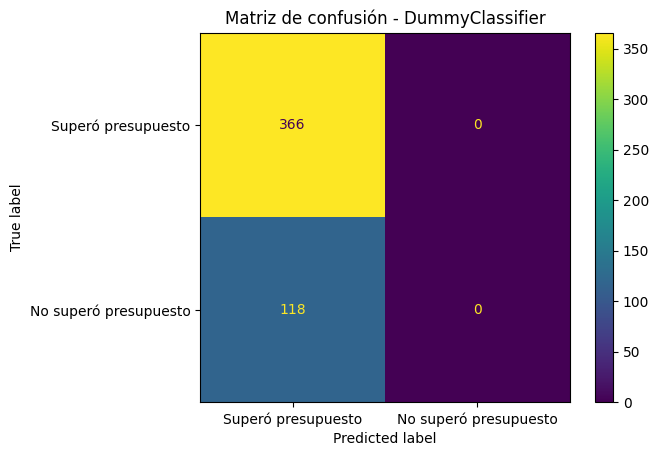

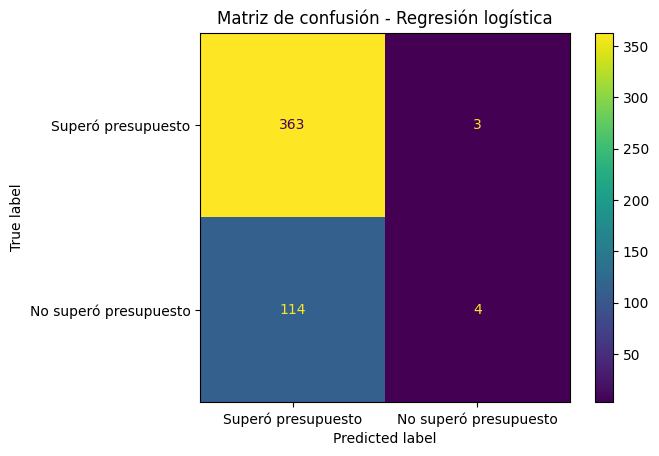

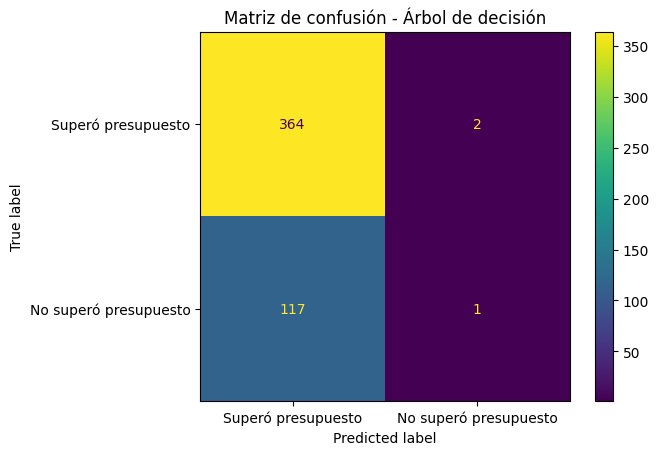

In [ ]:
modelos_predicciones = {
    "DummyClassifier": y_val_baseline,
    "Regresión logística": y_val_logistica,
    "Árbol de decisión": y_val_arbol
}

for nombre, predicciones in modelos_predicciones.items():

    matriz = confusion_matrix(
        y_val,
        predicciones
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=[
            "Superó presupuesto",
            "No superó presupuesto"
        ]
    ).plot()

    plt.title(
        f"Matriz de confusión - {nombre}"
    )

    plt.show()

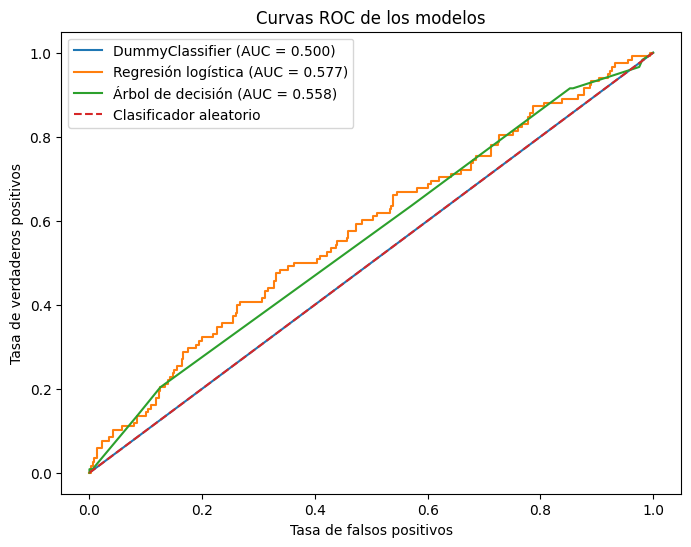

In [ ]:
fpr_baseline, tpr_baseline, _ = roc_curve(
    y_val,
    y_prob_baseline
)

fpr_logistica, tpr_logistica, _ = roc_curve(
    y_val,
    y_prob_logistica
)

fpr_arbol, tpr_arbol, _ = roc_curve(
    y_val,
    y_prob_arbol
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f"DummyClassifier (AUC = {roc_auc_score(y_val, y_prob_baseline):.3f})"
)

plt.plot(
    fpr_logistica,
    tpr_logistica,
    label=f"Regresión logística (AUC = {roc_auc_score(y_val, y_prob_logistica):.3f})"
)

plt.plot(
    fpr_arbol,
    tpr_arbol,
    label=f"Árbol de decisión (AUC = {roc_auc_score(y_val, y_prob_arbol):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title("Curvas ROC de los modelos")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()

plt.show()

### Interpretación de la curva ROC

La Regresión Logística obtiene el mejor `ROC-AUC` con **0.577**, seguida del Árbol de Decisión con **0.558**.

El baseline queda en **0.500**, que corresponde a una capacidad de separación equivalente al azar.

Los resultados muestran una pequeña mejora frente al baseline, pero todavía existe bastante margen para mejorar.

### Selección del modelo

La decisión no se basa solamente en `accuracy`.

El baseline ya mostró que es posible obtener alrededor de **75% de accuracy** sin detectar un solo caso de riesgo. Por eso se comparan principalmente `recall`, F1-score, ROC-AUC y los falsos negativos.

Con estos criterios, la Regresión Logística es el mejor punto de partida de los modelos probados.

### Conclusión de la evaluación inicial

La **Regresión Logística** presenta el mejor resultado inicial entre los modelos evaluados.

Aun así, su `recall` de **3.39%** es demasiado bajo para considerar que el problema está resuelto. El modelo supera al baseline y al Árbol de Decisión, pero todavía necesita ajustes importantes para detectar una mayor proporción de películas con riesgo.

## 17. Análisis de los errores de clasificación

Además de revisar las métricas generales, se analiza qué tipo de errores está cometiendo cada modelo.

Esto ayuda a entender por qué un modelo puede verse aceptable en accuracy y aun así ser poco útil para el objetivo real del proyecto.

### Interpretación de la matriz de confusión

- **Verdadero positivo (VP):** el modelo identifica una película como riesgo comercial y realmente no superó su presupuesto.

- **Verdadero negativo (VN):** el modelo identifica una película como sin riesgo comercial y realmente superó su presupuesto.

- **Falso positivo (FP):** el modelo identifica una película como riesgosa, pero en realidad sí superó su presupuesto.

- **Falso negativo (FN):** el modelo identifica una película como si fuera a superar su presupuesto, pero en realidad no lo superó.

### Tipos de error y su impacto

| Tipo de error | Interpretación | Posible costo |
|---|---|---|
| **Falso positivo** | Una película es clasificada con riesgo comercial, pero realmente supera su presupuesto. | Podría provocar revisiones adicionales, decisiones demasiado conservadoras o asignación innecesaria de recursos de seguimiento. |
| **Falso negativo** | Una película es clasificada como si fuera a superar su presupuesto, pero realmente no lo hace. | El estudio podría subestimar el riesgo del proyecto y no aplicar suficiente revisión, seguimiento o ajustes antes del estreno. |

### Error de mayor importancia

El error más importante en este proyecto es el **falso negativo**.

Un falso negativo significa que una película realmente tenía riesgo comercial, pero el modelo la clasificó como si no lo tuviera. En una situación real esto podría hacer que se tomara una decisión demasiado optimista sobre un proyecto riesgoso.

Por eso se busca mejorar principalmente el `recall`.

El `recall` indica qué proporción de todos los casos reales de riesgo fueron detectados correctamente.

Un recall bajo significa que el modelo está dejando pasar muchos falsos negativos. En este proyecto, aumentar esta métrica es una de las prioridades para la siguiente fase.

### Errores observados en los modelos iniciales

En la **Regresión Logística**, la matriz de confusión mostró:

- **363 verdaderos negativos**
- **3 falsos positivos**
- **114 falsos negativos**
- **4 verdaderos positivos**

Esto significa que el modelo identificó correctamente solamente **4 de las 118 películas que realmente presentaban riesgo comercial**, mientras que dejó sin detectar 114 casos.

En el **Árbol de Decisión** se observaron:

- **364 verdaderos negativos**
- **2 falsos positivos**
- **117 falsos negativos**
- **1 verdadero positivo**

En este caso, el modelo solamente identificó correctamente una película con riesgo comercial y dejó sin detectar 117 casos.

Los resultados confirman que ambos modelos dejan demasiados falsos negativos.

La Regresión Logística obtiene un `recall` de **3.39%** y el Árbol de Decisión solamente **0.85%**. Aunque la Regresión Logística es mejor, todavía detecta una parte muy pequeña de los casos de riesgo.

### Relación con las métricas de evaluación

Aunque aumentar el `recall` es importante, tampoco conviene ignorar la `precision`.

Si se intenta detectar demasiados casos de riesgo, el modelo podría terminar generando muchas falsas alertas. Por eso el objetivo es encontrar un mejor equilibrio entre ambas métricas y no optimizar una sola de forma aislada.

### Por qué accuracy no es suficiente

El `DummyClassifier` obtuvo **75.62% de accuracy** sin detectar ninguna película con riesgo.

Este resultado muestra claramente que una accuracy alta no significa necesariamente que el modelo sea útil. Para este problema es más importante revisar qué ocurre con la clase positiva y con los falsos negativos.

### Conclusión del análisis de errores

El principal problema de los modelos iniciales es la cantidad de **falsos negativos**.

La Regresión Logística sigue siendo la mejor opción de las probadas, pero con el umbral normal todavía deja sin detectar casi todos los casos de riesgo. Esto justifica analizar el umbral de decisión y probar mejoras adicionales en la siguiente fase.

## 18. Análisis del umbral de decisión

La Regresión Logística produce una probabilidad de pertenecer a `CommercialRisk = 1`.

Por defecto se usa un umbral de **0.50**: si la probabilidad es igual o mayor, se predice riesgo. Como el recall obtenido con ese valor fue muy bajo, también se prueba un umbral de **0.30** para ver cómo cambia el equilibrio entre `precision` y `recall`.

In [ ]:
print("Primeras probabilidades estimadas:")
print(y_prob_logistica[:10])

Primeras probabilidades estimadas:
[0.03881571 0.25148345 0.08514828 0.25906724 0.09130003 0.05591423
 0.03174547 0.42568743 0.16652174 0.18057364]


Cada valor representa la probabilidad que el modelo asigna a que una película tenga riesgo comercial.

Después, esa probabilidad se convierte en una clase usando el umbral seleccionado.

In [ ]:
umbrales = [0.50, 0.30]

resultados_umbral = []

for umbral in umbrales:

    y_pred_umbral = (
        y_prob_logistica >= umbral
    ).astype(int)

    resultados_umbral.append({
        "Umbral": umbral,
        "Precision": precision_score(
            y_val,
            y_pred_umbral,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            y_pred_umbral,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_val,
            y_pred_umbral,
            zero_division=0
        ),
        "Predicciones positivas": y_pred_umbral.sum()
    })

tabla_umbrales = pd.DataFrame(resultados_umbral)

tabla_umbrales

,Umbral,Precision,Recall,F1-score,Predicciones positivas
0,0.5,0.571429,0.033898,0.064000,7
1,0.3,0.345238,0.245763,0.287129,84


In [ ]:
tabla_umbrales_redondeada = tabla_umbrales.copy()

tabla_umbrales_redondeada[
    ["Precision", "Recall", "F1-score"]
] = tabla_umbrales_redondeada[
    ["Precision", "Recall", "F1-score"]
].round(4)

tabla_umbrales_redondeada

,Umbral,Precision,Recall,F1-score,Predicciones positivas
0,0.5,0.5714,0.0339,0.0640,7
1,0.3,0.3452,0.2458,0.2871,84


### Efecto del umbral sobre las predicciones

Al bajar el umbral, el modelo necesita menos probabilidad para marcar una película como riesgosa.

Esto normalmente aumenta el `recall` porque detecta más positivos, pero también puede generar más falsos positivos y hacer que baje la `precision`.

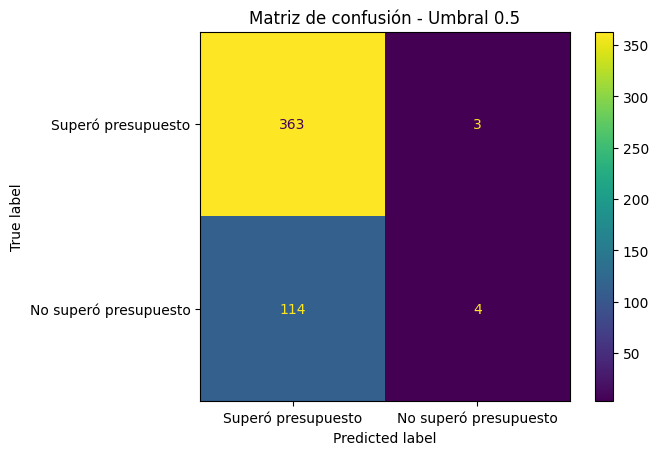

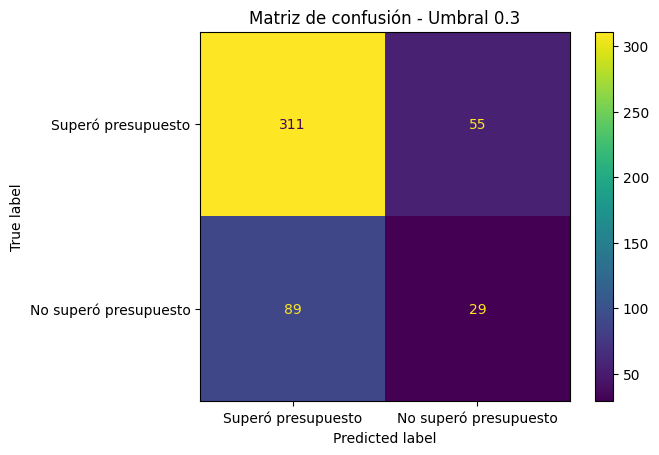

In [ ]:
for umbral in umbrales:

    y_pred_umbral = (
        y_prob_logistica >= umbral
    ).astype(int)

    matriz = confusion_matrix(
        y_val,
        y_pred_umbral
    )

    ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=[
            "Superó presupuesto",
            "No superó presupuesto"
        ]
    ).plot()

    plt.title(
        f"Matriz de confusión - Umbral {umbral}"
    )

    plt.show()

### Comparación de umbrales

| Umbral | Precision | Recall | F1-score | Observación |
|---|---:|---:|---:|---|
| **0.50** | **57.14%** | **3.39%** | **6.40%** | Mayor precision, pero detecta muy pocos casos de riesgo. |
| **0.30** | **34.52%** | **24.58%** | **28.71%** | Detecta muchos más casos de riesgo, aunque genera más falsos positivos. |

### Interpretación de los resultados

Al bajar el umbral de **0.50 a 0.30**, el cambio es bastante claro.

Con 0.50, la Regresión Logística tiene **57.14% de precision**, pero solamente **3.39% de recall**, ya que detecta 4 de las 118 películas con riesgo.

Con 0.30, el recall sube a **24.58%** y se detectan 29 casos de riesgo. A cambio, la precision baja a **34.52%** porque aumentan los falsos positivos.

El F1-score también mejora de **6.40% a 28.71%**, por lo que 0.30 da un mejor equilibrio inicial entre precision y recall.

Esto no significa que 0.30 sea el umbral final, pero sí demuestra que el comportamiento del modelo puede ajustarse bastante dependiendo del costo de cada tipo de error.

### Relación entre precision y recall

Cambiar el umbral produce un intercambio entre `precision` y `recall`.

Un umbral alto hace al modelo más conservador: genera menos alertas, pero puede dejar muchos casos reales sin detectar.

Un umbral más bajo detecta más casos de riesgo, aunque también aumenta las falsas alertas.

Por eso, el umbral final debe elegirse considerando qué error resulta más costoso para el uso real del modelo.

### Conclusión del análisis del umbral

El umbral tiene un efecto importante en el comportamiento de la Regresión Logística.

Bajarlo de 0.50 a 0.30 mejora bastante el recall y el F1-score, aunque reduce la precision.

Por ahora no se fija un umbral definitivo. La prueba solamente muestra que esta será una decisión importante en la siguiente fase y que debe tomarse junto con las métricas y el costo de los errores.

## 19. Selección del modelo preliminar

Con los resultados obtenidos en validación, se selecciona la **Regresión Logística** como modelo preliminar.

No es porque ya tenga un desempeño suficiente, sino porque fue el mejor de los modelos iniciales, es fácil de interpretar y permite ajustar su comportamiento modificando el umbral de decisión.

### Tabla de decisión del modelo preliminar

| Criterio | Modelo seleccionado | Justificación |
|---|---|---|
| **Desempeño general** | Regresión Logística | Obtuvo el mejor desempeño global entre los modelos iniciales, con `accuracy = 75.83%` y `ROC-AUC = 0.577`. |
| **Recall de riesgo comercial** | Regresión Logística | Con el umbral 0.50 obtuvo `recall = 3.39%`, superior al 0.85% del Árbol de Decisión. Además, al probar un umbral de 0.30 el recall aumentó a 24.58%. |
| **Equilibrio precision-recall** | Regresión Logística | Presentó mejor F1-score que el árbol. Con umbral 0.30 alcanzó un F1-score de 28.71%, mostrando que existe margen para mejorar el equilibrio mediante el ajuste del umbral. |
| **Interpretabilidad** | Regresión Logística | Permite analizar de manera relativamente sencilla cómo las variables influyen en la probabilidad estimada de riesgo comercial. |
| **Complejidad** | Regresión Logística | Es un modelo relativamente simple y fácil de reproducir, lo cual resulta adecuado para esta etapa inicial del proyecto. |
| **Estabilidad** | Regresión Logística | Al ser un modelo lineal regularizado, suele presentar un comportamiento más estable frente a pequeñas variaciones de los datos que un único árbol de decisión. |
| **Riesgo operativo** | Regresión Logística | Aunque actualmente existen muchos falsos negativos, el modelo permite modificar el umbral de decisión para aumentar la detección de películas con riesgo y adaptar posteriormente el modelo al costo de los errores. |

### Justificación de la selección

La Regresión Logística supera al Árbol de Decisión en las métricas principales de esta primera comparación.

Con umbral 0.50 obtiene `ROC-AUC = 0.577`, `recall = 3.39%` y `F1-score = 6.40%`. El Árbol de Decisión obtiene `ROC-AUC = 0.558`, `recall = 0.85%` y `F1-score = 1.65%`.

Los resultados todavía son bajos, pero la Regresión Logística ofrece un mejor punto de partida para seguir trabajando.

El análisis del umbral refuerza esa decisión.

Al pasar de 0.50 a 0.30, el `recall` sube de **3.39% a 24.58%** y el `F1-score` de **6.40% a 28.71%**.

Esto no convierte al modelo en una solución final, pero sí muestra que todavía existe margen para mejorar su comportamiento sin cambiar de algoritmo.

### Conclusión de la selección preliminar

La **Regresión Logística** queda seleccionada como el modelo preliminar para la siguiente fase.

Fue el modelo con mejor desempeño inicial y además es sencillo de interpretar y ajustar. Su principal problema sigue siendo la gran cantidad de falsos negativos.

En la entrega final se buscará mejorar este punto mediante ajuste de hiperparámetros, tratamiento del desbalance, comparación con modelos más potentes y selección de un mejor umbral.

## 20. Plan de mejora para la entrega final

La Regresión Logística sirve como una buena línea base, pero los resultados muestran claramente que todavía falta mejorar.

Con el umbral de 0.50 el recall es solamente **3.39%**. Al bajarlo a 0.30 aumenta a **24.58%**, pero todavía se deja sin detectar una parte importante de las películas con riesgo.

La siguiente fase se enfocará en reducir falsos negativos, mejorar la capacidad de separación del modelo y comprobar que las mejoras se mantengan con una validación más sólida.

### Acciones propuestas

| Acción de mejora | Propuesta | Justificación |
|---|---|---|
| **Modelos avanzados** | Comparar Random Forest y Gradient Boosting con la Regresión Logística seleccionada. | Los modelos actuales presentan una capacidad de separación limitada. Estos algoritmos pueden capturar relaciones no lineales e interacciones entre variables que la regresión logística puede no representar. |
| **Ajuste de hiperparámetros** | Ajustar parámetros como `C`, `penalty` y `class_weight` en Regresión Logística; y `n_estimators`, `max_depth`, `min_samples_split` y `class_weight` en modelos de árboles. | Puede mejorar la detección de la clase positiva y reducir el alto número de falsos negativos observado en esta fase. |
| **Validación cruzada** | Utilizar `StratifiedKFold` con aproximadamente 5 particiones. | Permitirá evaluar los modelos en varias divisiones manteniendo la proporción de clases y reducir la dependencia de una sola partición de validación. |
| **Selección de características** | Evaluar regularización L1, importancia por permutación o métodos como `SelectKBest`. | El One-Hot Encoding generó 352 variables, por lo que algunas podrían aportar muy poca información y aumentar innecesariamente la complejidad. |
| **Interpretabilidad** | Analizar coeficientes de Regresión Logística y utilizar importancia por permutación o SHAP en modelos más complejos. | Permitirá entender qué variables influyen más en la estimación del riesgo comercial y facilitar la interpretación de las predicciones. |
| **Revisión por subgrupos** | Comparar métricas por género, idioma, rango de presupuesto y periodo de estreno. | Permitirá identificar si el modelo funciona mejor o peor para determinados tipos de películas y detectar posibles sesgos o diferencias importantes de desempeño. |
| **Serialización del pipeline** | Guardar el pipeline completo mediante `joblib`. | Permitirá reutilizar exactamente el mismo preprocesamiento y modelo sin tener que entrenarlos nuevamente. |
| **Mecanismo de inferencia** | Crear una función que reciba las características de una película y devuelva probabilidad de riesgo y clasificación según un umbral. | Permitirá utilizar el modelo con nuevas películas de manera sencilla y reproducible. |
| **Monitoreo** | Vigilar distribución de variables, proporción de predicciones positivas, valores faltantes, categorías nuevas y métricas reales cuando se conozca la taquilla. | Permitirá detectar cambios en los datos o disminuciones en el desempeño del modelo con el paso del tiempo. |

### Modelos avanzados

Se mantendrá la Regresión Logística como referencia y se comparará con **Random Forest** y **Gradient Boosting**.

Estos modelos pueden capturar relaciones no lineales e interacciones que la regresión logística puede no representar.

La comparación tiene sentido porque los ROC-AUC iniciales están todavía muy cerca de 0.5.

### Ajuste de hiperparámetros

En la Regresión Logística se probarán diferentes valores de `C`, regularización y `class_weight`.

`class_weight` puede ser especialmente útil por el desbalance de clases y por la gran cantidad de falsos negativos.

En los modelos de árboles también se ajustarán parámetros como profundidad, número de árboles y número mínimo de observaciones por división.

Todo este ajuste se realizará usando validación, sin tocar el conjunto de prueba.

### Estrategia de validación cruzada

Para comparar configuraciones se propone utilizar `StratifiedKFold` con 5 particiones.

Esto permitirá evaluar cada modelo en varias divisiones manteniendo aproximadamente la misma proporción de clases.

El conjunto de prueba seguirá completamente aislado hasta elegir la configuración final.

### Selección de características

Después del One-Hot Encoding, las 10 variables originales se convierten en **352 características**.

No necesariamente todas aportan información útil. En la siguiente fase se podrá revisar esto con regularización L1, importancia por permutación o métodos como `SelectKBest`.

Reducir variables poco útiles podría hacer el modelo más simple y disminuir el riesgo de sobreajuste.

### Interpretabilidad del modelo

Si la Regresión Logística se mantiene entre los mejores modelos, sus coeficientes pueden ayudar a entender qué características aumentan o reducen la probabilidad estimada de riesgo.

Para modelos más complejos se podrán usar herramientas como importancia por permutación o SHAP.

La idea es que el modelo sirva como apoyo para una decisión y que sus resultados puedan explicarse.

### Revisión del desempeño por subgrupos

También se revisará si el modelo funciona igual de bien para distintos grupos, por ejemplo:

- Género cinematográfico.
- Idioma original.
- Rango de presupuesto.
- Periodo de estreno.

Para cada grupo se podrán comparar `recall`, `precision` y tasa de falsos negativos.

Esto permitirá detectar si el modelo funciona considerablemente peor en algún tipo de película.

### Serialización del pipeline

Cuando se seleccione el modelo final, se guardará el pipeline completo con una herramienta como `joblib`.

Así se conservarán juntos el preprocesamiento y el clasificador, evitando tener que reconstruir manualmente los mismos pasos cada vez que se quiera hacer una predicción.

### Mecanismo mínimo de inferencia

Se creará una función sencilla que reciba los datos de una nueva película y devuelva:

1. La probabilidad estimada de riesgo comercial.
2. La clasificación final según el umbral elegido.

Esto permitirá usar el pipeline completo sin repetir manualmente la limpieza, codificación y escalamiento.

### Plan inicial de monitoreo

Si el modelo llegara a utilizarse con datos nuevos, sería necesario revisar si su comportamiento cambia con el tiempo.

Se podrían monitorear:

- Distribución de presupuesto, duración, género y año.
- Categorías nuevas.
- Aumento de valores faltantes.
- Proporción de predicciones de riesgo.
- Precision, recall, F1-score y ROC-AUC cuando se conozcan los resultados reales.
- Desempeño por subgrupos.
- Necesidad de recalibrar el umbral.

Si aparecen cambios importantes, habría que considerar actualizar o volver a entrenar el modelo.

### Limitaciones actuales

En este avance se identifican varias limitaciones importantes:

1. **Recall todavía bajo.** Incluso con el umbral de 0.30, el modelo detecta solamente 24.58% de las películas con riesgo, por lo que siguen existiendo muchos falsos negativos.
2. **Capacidad de separación limitada.** El mejor ROC-AUC inicial es 0.577, todavía cercano a 0.5.
3. **Alta cardinalidad.** Después del One-Hot Encoding se generan 352 características, principalmente por variables como director, actor y productora.
4. **Limitaciones del dataset.** Muchos registros tienen `budget` o `revenue` igual a cero y no pueden utilizarse para construir de forma confiable la variable objetivo.

### Conclusión del plan de mejora

El avance deja una línea base funcional y reproducible, pero todavía no un modelo listo para usarse como solución final.

La siguiente etapa se enfocará principalmente en mejorar el recall y reducir falsos negativos mediante nuevos modelos, ajuste de hiperparámetros, validación cruzada, selección de características y revisión del umbral.

El conjunto de prueba seguirá aislado hasta seleccionar la mejor configuración.

## 21. Reproducibilidad y trazabilidad del proyecto

Para poder repetir el experimento se documentan los archivos utilizados, la semilla, las particiones, el pipeline, las configuraciones de los modelos y las métricas obtenidas.

Se utiliza `random_state = 42` tanto en la partición como en los modelos que necesitan una semilla.

También se registran las versiones principales del entorno para que futuras ejecuciones puedan compararse bajo condiciones similares.

In [ ]:
import sys
import platform
import pandas as pd
import numpy as np
import sklearn
import matplotlib

print("Python:", sys.version.split()[0])
print("Sistema:", platform.platform())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.13.15
Sistema: Linux-6.6.122+-x86_64-with-glibc2.35
Pandas: 2.2.3
NumPy: 2.1.3
Scikit-learn: 1.6.1
Matplotlib: 3.10.0


### Versiones del entorno

Se registran las versiones de Python, Pandas, NumPy, Scikit-learn y Matplotlib.

Esto ayuda a reproducir el proyecto porque algunas funciones pueden comportarse diferente entre versiones.

In [ ]:
from datetime import datetime

fecha_ejecucion = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("Fecha de ejecución:", fecha_ejecucion)

Fecha de ejecución: 2026-09-01 07:36:10


### Tabla de trazabilidad inicial

| Elemento | Detalle |
|---|---|
| **Dataset** | TMDB 5000 Movie Dataset |
| **Fuente** | Kaggle / The Movie Database (TMDB) |
| **Fecha de consulta** | 2026-09-01 |
| **Archivos del dataset** | `tmdb_5000_movies.csv`, `tmdb_5000_credits.csv` |
| **Semilla** | `random_state = 42` |
| **Partición** | 70% entrenamiento, 15% validación, 15% prueba |
| **Pipeline** | `ColumnTransformer` con imputación, `log1p`, `StandardScaler` y `OneHotEncoder` |
| **Baseline** | `DummyClassifier(strategy="most_frequent")` |
| **Modelos comparados** | Regresión Logística y Árbol de Decisión |
| **Regresión Logística** | `max_iter=1000`, `random_state=42` |
| **Árbol de Decisión** | `max_depth=5`, `random_state=42` |
| **Métricas** | Accuracy, Precision, Recall, F1-score, ROC-AUC y matriz de confusión |
| **Entorno de ejecución** | Google Colab |
| **Archivo principal** | `AvanceProyecto_final_revisado.ipynb` |
| **Fecha de ejecución** | 2026-09-01 |

### Resultados registrados

| Modelo | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| **DummyClassifier** | 0.7562 | 0.0000 | 0.0000 | 0.0000 | 0.5000 |
| **Regresión Logística** | 0.7583 | 0.5714 | 0.0339 | 0.0640 | 0.5770 |
| **Árbol de Decisión** | 0.7541 | 0.3333 | 0.0085 | 0.0165 | 0.5576 |

### Resultados del análisis de umbral

| Umbral | Precision | Recall | F1-score |
|---|---:|---:|---:|
| **0.50** | 0.5714 | 0.0339 | 0.0640 |
| **0.30** | 0.3452 | 0.2458 | 0.2871 |

El análisis del umbral se realizó sobre la Regresión Logística utilizando el conjunto de validación.

### Configuración del pipeline

El preprocesamiento final utilizado en este avance queda así:

- `budget`: imputación con mediana → `log1p` → `StandardScaler`.
- `runtime` y `release_year`: imputación con mediana → `StandardScaler`.
- Variables categóricas: imputación con `Unknown` → `OneHotEncoder`.
- Categorías desconocidas: `handle_unknown="ignore"`.
- Categorías poco frecuentes: `min_frequency=5`.

Después del preprocesamiento, las 10 variables originales se transforman en **352 características**.

El pipeline se ajusta solamente con entrenamiento para evitar fuga de información.

## Conclusión general del avance

En este avance se construyó una primera versión completa y reproducible del proyecto para identificar películas con riesgo de no superar su presupuesto en taquilla.

Se preparó el dataset, se revisó su calidad, se evitó fuga de información, se realizó una partición 70/15/15 y se construyó un pipeline que se ajusta únicamente con los datos de entrenamiento.

Como referencia se probó un `DummyClassifier` y después se compararon Regresión Logística y Árbol de Decisión. La **Regresión Logística** obtuvo el mejor desempeño inicial, con `ROC-AUC = 0.577`, aunque su `recall = 3.39%` con el umbral normal sigue siendo demasiado bajo. Al probar un umbral de 0.30, el recall aumentó a **24.58%**, mostrando que existe margen de mejora.

La principal conclusión es que ya existe una base funcional para continuar, pero el modelo todavía no detecta suficientes casos de riesgo. Para la entrega final se buscará mejorar principalmente el recall y reducir falsos negativos mediante modelos adicionales, ajuste de hiperparámetros, validación cruzada, selección de características y análisis del umbral.

El conjunto de prueba se mantiene sin utilizar para poder hacer una evaluación final más confiable después de seleccionar la mejor configuración.